# Multi-Modal Liveness Detection System
## Project Report — BS4AI

**Objective:** Develop a multi-modal liveness detection system that combines visual and audio information to distinguish live users from presentation attacks (replay attacks and AI-generated deepfakes).

**Hypothesis:** Integrating visual and acoustic cues will improve liveness detection performance compared to single-modality approaches and provide a more reliable basis for evaluating demographic bias.

**Experiment v3 (current tooling):** Run `python scripts/full_experiment.py` (default `outputs/experiment_v3`). Metrics use **oriented spoof scores** (`scores_flipped`, `auc_raw`, `eer_before_symmetry` in JSON): if raw AUC is below 0.5, scores are reflected; reported EER uses `min(eer, 1-eer)` so it never exceeds 50%. CLI options include `--n-samples`, `--num-frames`, `--visual-backbone`, `--face-detector`, `--kfold`, and `--amp` (CUDA mixed precision in `Trainer`).

**FairFace fairness (Phase 3):** With FairFace installed under `paths.fairface` in `config/data_config.yaml`, run  
`python scripts/run_fairness_eval.py --visual-checkpoint outputs/experiment_v3/visual/best_model.pt --experiment-summary outputs/experiment_v3/results/experiment_summary.json`.

---

### Table of Contents
1. [Project Setup & Data Overview](#1-project-setup--data-overview)
2. [Data Exploration](#2-data-exploration)
3. [Model Architectures](#3-model-architectures)
4. [Experiment v1 — Baseline Results](#4-experiment-v1--baseline-results)
5. [Experiment v2 / v3 — Improved Results](#5-experiment-v2--improved-results)
6. [v1 vs v2 Comparison](#6-v1-vs-v2-comparison)
7. [Detailed Analysis](#7-detailed-analysis)
8. [Fairness Evaluation Framework](#8-fairness-evaluation-framework)
9. [Conclusions & Next Steps](#9-conclusions--next-steps)

In [1]:
import sys, os, json, warnings
from pathlib import Path
from IPython.display import display, Image, Markdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'figure.facecolor': 'white'})

# Project root
PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

# Prefer v3 experiment outputs when present
EXP_RESULTS_V3 = PROJECT_ROOT / 'outputs' / 'experiment_v3' / 'results' / 'experiment_summary.json'
EXP_CHARTS_V3 = PROJECT_ROOT / 'outputs' / 'experiment_v3' / 'charts'
EXP_RESULTS_V2 = PROJECT_ROOT / 'outputs' / 'experiment_v2' / 'results' / 'experiment_summary.json'
EXP_CHARTS_V2 = PROJECT_ROOT / 'outputs' / 'experiment_v2' / 'charts'

print(f'Project root: {PROJECT_ROOT}')
print(f'Python: {sys.version.split()[0]}')
print(f'v3 summary exists: {EXP_RESULTS_V3.exists()} | v2 summary exists: {EXP_RESULTS_V2.exists()}')

Project root: /Users/SaiDinesh/Documents/BS4AI-Project
Python: 3.11.13


---
## 1. Project Setup & Data Overview

### Datasets Used

| Dataset | Purpose | Modality | Samples Available |
|---------|---------|----------|------------------|
| **FaceForensics++ (C23)** | Visual deepfake detection | Video | 1,000 real + 5,000 fake videos |
| **ASVspoof 2019 (LA)** | Audio spoofing detection | Audio | 2,580 bonafide + 22,800 spoof (train) |
| **FairFace** | Fairness evaluation | Demographics | Used for FRR analysis by race/gender |

In [2]:
# Load data configuration
from src.data.sampling import load_data_config
config = load_data_config(str(PROJECT_ROOT / 'config' / 'data_config.yaml'))

print('=== Data Configuration ===')
print(f'Sampling: n={config["sampling"]["n_per_dataset"]}, seed={config["sampling"]["seed"]}')
print(f'FF++ C23 path: {config["paths"]["ff_c23"]}')
print(f'ASVspoof path: {config["paths"]["asvspoof2019"]}')
print(f'\nFF++ categories (real): {config["ff_c23"]["categories"]["real"]}')
print(f'FF++ categories (fake): {config["ff_c23"]["categories"]["fake"]}')
print(f'\nAudio: sr={config["asvspoof2019"]["audio"]["sample_rate"]}Hz, '
      f'LFCC={config["asvspoof2019"]["audio"]["n_lfcc"]}, '
      f'max_len={config["asvspoof2019"]["audio"]["max_length"]/config["asvspoof2019"]["audio"]["sample_rate"]}s')

=== Data Configuration ===
Sampling: n=200, seed=42
FF++ C23 path: data/FaceForensics++_C23
ASVspoof path: data/LA/LA

FF++ categories (real): ['original']
FF++ categories (fake): ['Deepfakes', 'Face2Face', 'FaceSwap', 'NeuralTextures', 'FaceShifter']

Audio: sr=16000Hz, LFCC=60, max_len=4.0s


---
## 2. Data Exploration

=== FaceForensics++ C23 Dataset ===


,Category,Count,Label,Avg Frames,Avg Size (MB)
0,original,1000,REAL,509.128,1.84677
1,Deepfakes,1000,FAKE,509.128,1.90042
2,Face2Face,1000,FAKE,509.128,1.85666
3,FaceSwap,1000,FAKE,406.140,1.56358
4,FaceShifter,1000,FAKE,509.128,1.82796
5,NeuralTextures,1000,FAKE,406.137,1.45529
6,DeepFakeDetection,1000,FAKE,733.791,6.63761


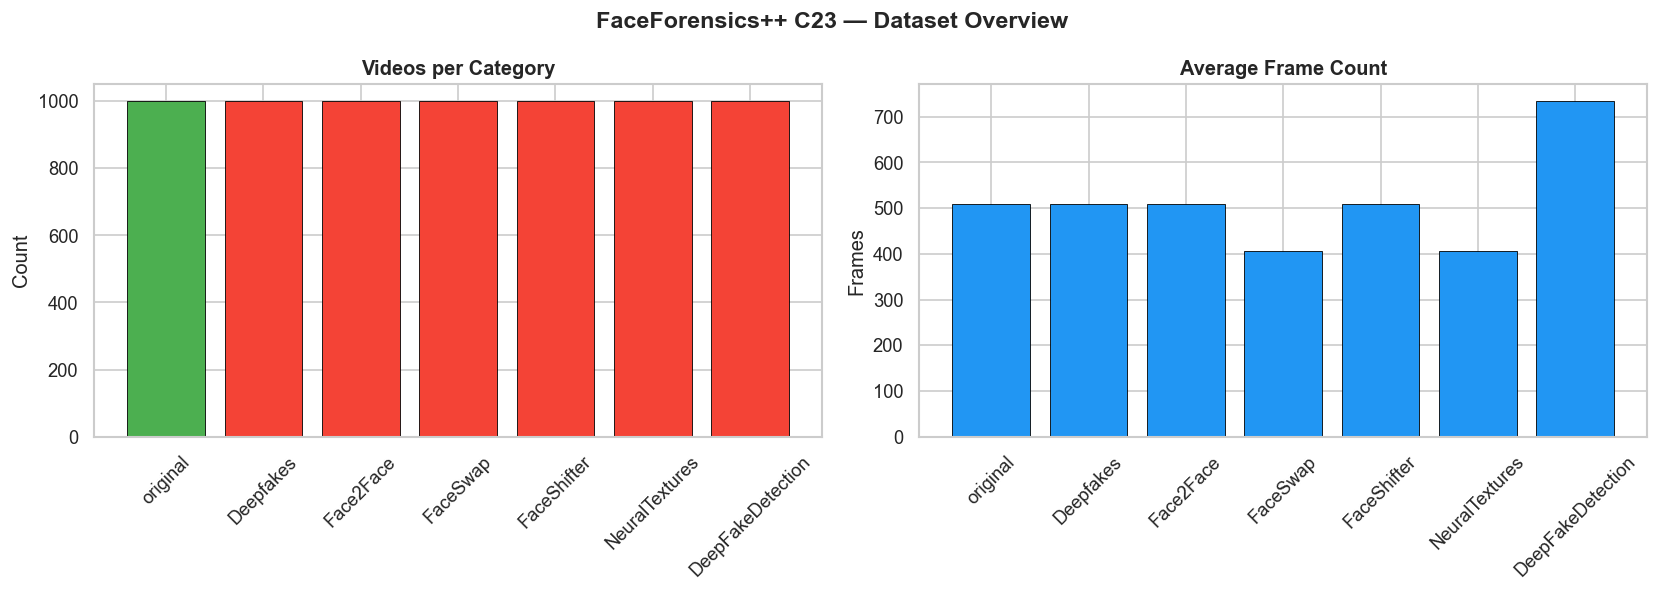

In [3]:
# FF++ C23 metadata analysis
csv_dir = PROJECT_ROOT / 'data' / 'FaceForensics++_C23' / 'csv'
categories = ['original', 'Deepfakes', 'Face2Face', 'FaceSwap', 'FaceShifter', 'NeuralTextures', 'DeepFakeDetection']

ff_stats = []
for cat in categories:
    csv_path = csv_dir / f'{cat}.csv'
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        ff_stats.append({
            'Category': cat,
            'Count': len(df),
            'Label': 'REAL' if cat == 'original' else 'FAKE',
            'Avg Frames': df['Frame Count'].mean(),
            'Avg Size (MB)': df['File Size(MB)'].mean(),
        })

ff_df = pd.DataFrame(ff_stats)
print('=== FaceForensics++ C23 Dataset ===')
display(ff_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4CAF50' if s == 'REAL' else '#F44336' for s in ff_df['Label']]
axes[0].bar(ff_df['Category'], ff_df['Count'], color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Videos per Category', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Count')

axes[1].bar(ff_df['Category'], ff_df['Avg Frames'], color='#2196F3', edgecolor='black', linewidth=0.5)
axes[1].set_title('Average Frame Count', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Frames')

plt.suptitle('FaceForensics++ C23 — Dataset Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== ASVspoof 2019 LA Dataset ===


,Split,Bonafide,Spoof,Total,Spoof Systems,Spoof Ratio
0,train,2580,22800,25380,6,89.8%
1,dev,2548,22296,24844,6,89.7%
2,eval,7355,63882,71237,13,89.7%


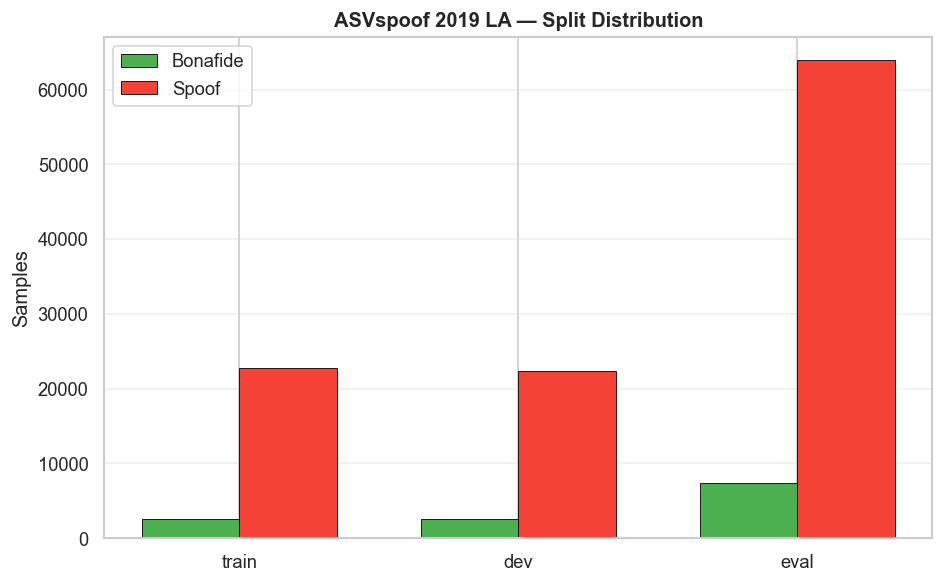

In [4]:
# ASVspoof 2019 LA protocol analysis
asvspoof_root = PROJECT_ROOT / 'data' / 'LA' / 'LA'

splits_info = []
for split, proto_file in [
    ('train', 'ASVspoof2019.LA.cm.train.trn.txt'),
    ('dev', 'ASVspoof2019.LA.cm.dev.trl.txt'),
    ('eval', 'ASVspoof2019.LA.cm.eval.trl.txt'),
]:
    proto_path = asvspoof_root / 'ASVspoof2019_LA_cm_protocols' / proto_file
    bonafide, spoof, systems = 0, 0, set()
    with open(proto_path) as f:
        for line in f:
            parts = line.strip().split()
            if parts[4] == 'bonafide':
                bonafide += 1
            else:
                spoof += 1
                systems.add(parts[3])
    splits_info.append({
        'Split': split, 'Bonafide': bonafide, 'Spoof': spoof,
        'Total': bonafide + spoof, 'Spoof Systems': len(systems),
        'Spoof Ratio': f'{spoof/(bonafide+spoof)*100:.1f}%',
    })

asv_df = pd.DataFrame(splits_info)
print('=== ASVspoof 2019 LA Dataset ===')
display(asv_df)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(3)
w = 0.35
ax.bar(x - w/2, asv_df['Bonafide'], w, label='Bonafide', color='#4CAF50', edgecolor='black', lw=0.5)
ax.bar(x + w/2, asv_df['Spoof'], w, label='Spoof', color='#F44336', edgecolor='black', lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(asv_df['Split'])
ax.set_ylabel('Samples')
ax.set_title('ASVspoof 2019 LA — Split Distribution', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
## 3. Model Architectures

### System Architecture
```
┌─────────────────────────────────────────────────────────────────┐
│              MULTI-MODAL LIVENESS DETECTION                     │
├──────────────────┬──────────────────┬──────────────────────────┤
│  VISUAL STREAM   │  AUDIO STREAM    │  FUSION & DECISION       │
│                  │                  │                          │
│  FF++ C23 videos │  ASVspoof 2019   │  Attention Fusion        │
│  ↓               │  ↓               │  ↓                      │
│  Face Detection  │  LFCC Features   │  Cross-modal weights     │
│  (Haar Cascade)  │  (60-dim)        │  ↓                      │
│  ↓               │  ↓               │  Liveness Score (0-1)    │
│  ResNet18        │  LCNN            │                          │
│  (frozen layers) │  (MFM activations│                          │
│  ↓               │  ↓               │                          │
│  512-dim embed   │  512-dim embed   │                          │
└──────────────────┴──────────────────┴──────────────────────────┘
```

| Component | Architecture | Key Details |
|-----------|-------------|-------------|
| **Visual Backbone** | ResNet18 (pretrained) | Frozen layers 0-5, 512-dim embedding, temporal avg pool over frames |
| **Audio Backbone** | LCNN (Light CNN) | Max Feature Map activations, 4 conv blocks, 512-dim embedding |
| **Fusion Module** | Attention Fusion | Learns modality weights, cross-modal compatibility, 256-dim hidden |

In [5]:
# Model parameter summary
import torch
from src.models.visual_backbone import VisualBackbone
from src.models.audio_backbone import AudioBackbone
from src.models.fusion import build_fusion

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

visual = VisualBackbone(embedding_dim=512, pretrained=False, freeze_layers=6)
audio = AudioBackbone(embedding_dim=512)
fusion = build_fusion('attention', visual_dim=512, audio_dim=512, hidden_dim=256)

models_info = []
for name, model in [('Visual (ResNet18)', visual), ('Audio (LCNN)', audio), ('Attention Fusion', fusion)]:
    total, trainable = count_params(model)
    models_info.append({'Model': name, 'Total Params': f'{total:,}', 'Trainable': f'{trainable:,}',
                        '% Trainable': f'{100*trainable/total:.1f}%'})

display(pd.DataFrame(models_info))

# Verify shapes
print('\n=== Shape Verification ===')
video_in = torch.randn(2, 4, 3, 224, 224)
audio_in = torch.randn(2, 1, 60, 200)
v_emb = visual.extract_features(video_in)
a_emb = audio.extract_features(audio_in)
fused = fusion(v_emb, a_emb)
print(f'Video input:    {tuple(video_in.shape)} → Visual embedding:  {tuple(v_emb.shape)}')
print(f'Audio input:    {tuple(audio_in.shape)} → Audio embedding:   {tuple(a_emb.shape)}')
print(f'Fusion output:  {tuple(fused.shape)} (logits for 2 classes)')

,Model,Total Params,Trainable,% Trainable
0,Visual (ResNet18),"11,441,218","11,441,218",100.0%
1,Audio (LCNN),"140,386","140,386",100.0%
2,Attention Fusion,"427,652","427,652",100.0%



=== Shape Verification ===


Video input:    (2, 4, 3, 224, 224) → Visual embedding:  (2, 512)
Audio input:    (2, 1, 60, 200) → Audio embedding:   (2, 512)
Fusion output:  (2, 2) (logits for 2 classes)


---
## 4. Experiment v1 — Baseline Results

**Configuration:** 100 samples per modality, no augmentation, no face detection, no frozen layers, simple late fusion (score-level weighted average).

In [6]:
# Load v1 results
v1_path = PROJECT_ROOT / 'outputs' / 'full_experiment' / 'results' / 'experiment_summary.json'
with open(v1_path) as f:
    v1 = json.load(f)

print('=== Experiment v1 — Baseline ===')
print(f'Device: {v1["experiment"]["device"]}')
print(f'Samples: {v1["experiment"]["n_samples"]} per modality')
print(f'Audio epochs: {v1["experiment"]["audio_epochs"]}, Visual epochs: {v1["experiment"]["visual_epochs"]}')
print(f'Total time: {v1["experiment"]["total_time_seconds"]}s')

v1_df = pd.DataFrame({
    'Metric': ['EER (%)', 'Accuracy (%)', 'AUC (%)', 'min t-DCF'],
    'Audio (LCNN)': [v1['audio_test_metrics']['eer']*100, v1['audio_test_metrics']['accuracy']*100,
                     v1['audio_test_metrics']['auc']*100, v1['audio_test_metrics']['min_tdcf']],
    'Visual (ResNet18)': [v1['visual_test_metrics']['eer']*100, v1['visual_test_metrics']['accuracy']*100,
                          v1['visual_test_metrics']['auc']*100, v1['visual_test_metrics']['min_tdcf']],
    'Late Fusion': [v1['fusion_test_metrics']['eer']*100, v1['fusion_test_metrics']['accuracy']*100,
                    v1['fusion_test_metrics']['auc']*100, v1['fusion_test_metrics']['min_tdcf']],
})
print()
display(v1_df.style.format(precision=2).set_caption('v1 Baseline Test Metrics'))

=== Experiment v1 — Baseline ===
Device: cpu
Samples: 100 per modality
Audio epochs: 15, Visual epochs: 12
Total time: 179.4s



,Metric,Audio (LCNN),Visual (ResNet18),Late Fusion
0,EER (%),16.00,63.64,50.00
1,Accuracy (%),84.00,40.00,53.33
2,AUC (%),91.76,40.91,50.00
3,min t-DCF,0.29,0.73,0.82


=== v1 Summary Dashboard ===


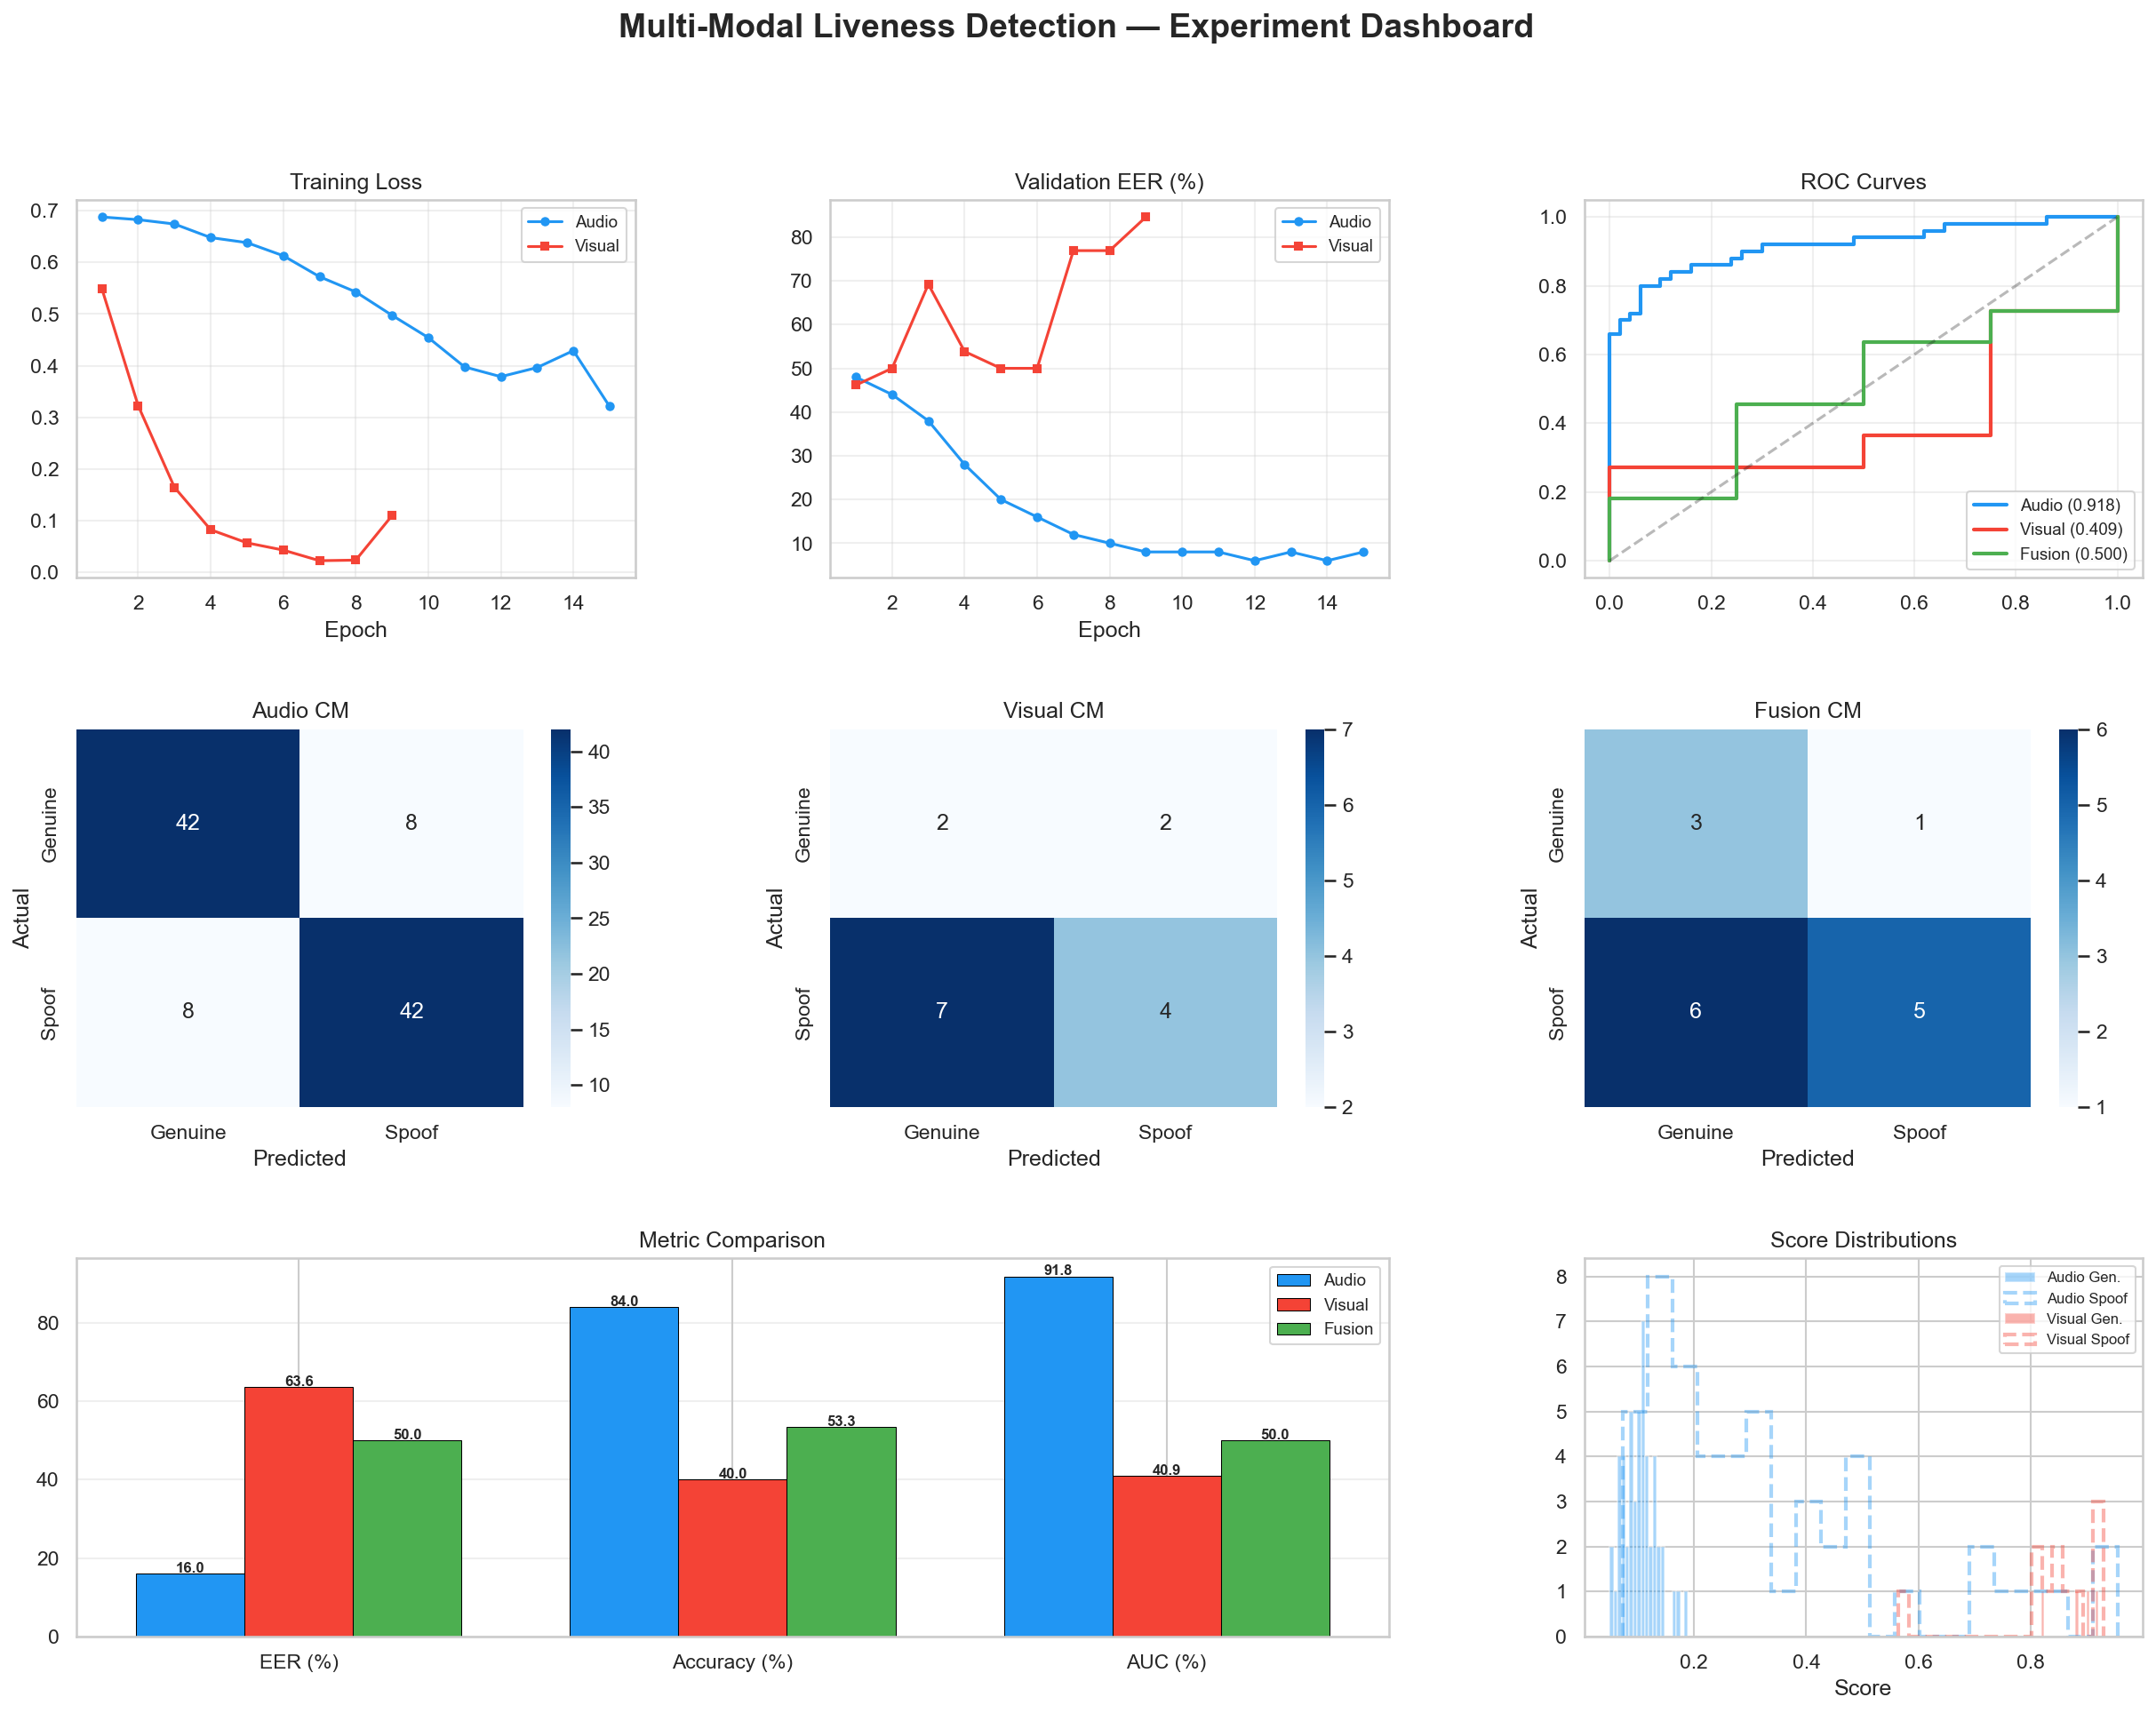

In [7]:
# Display v1 charts
v1_charts = PROJECT_ROOT / 'outputs' / 'full_experiment' / 'charts'

print('=== v1 Summary Dashboard ===')
display(Image(filename=str(v1_charts / 'summary_dashboard.png'), width=900))

=== v1 Audio Training Curves ===


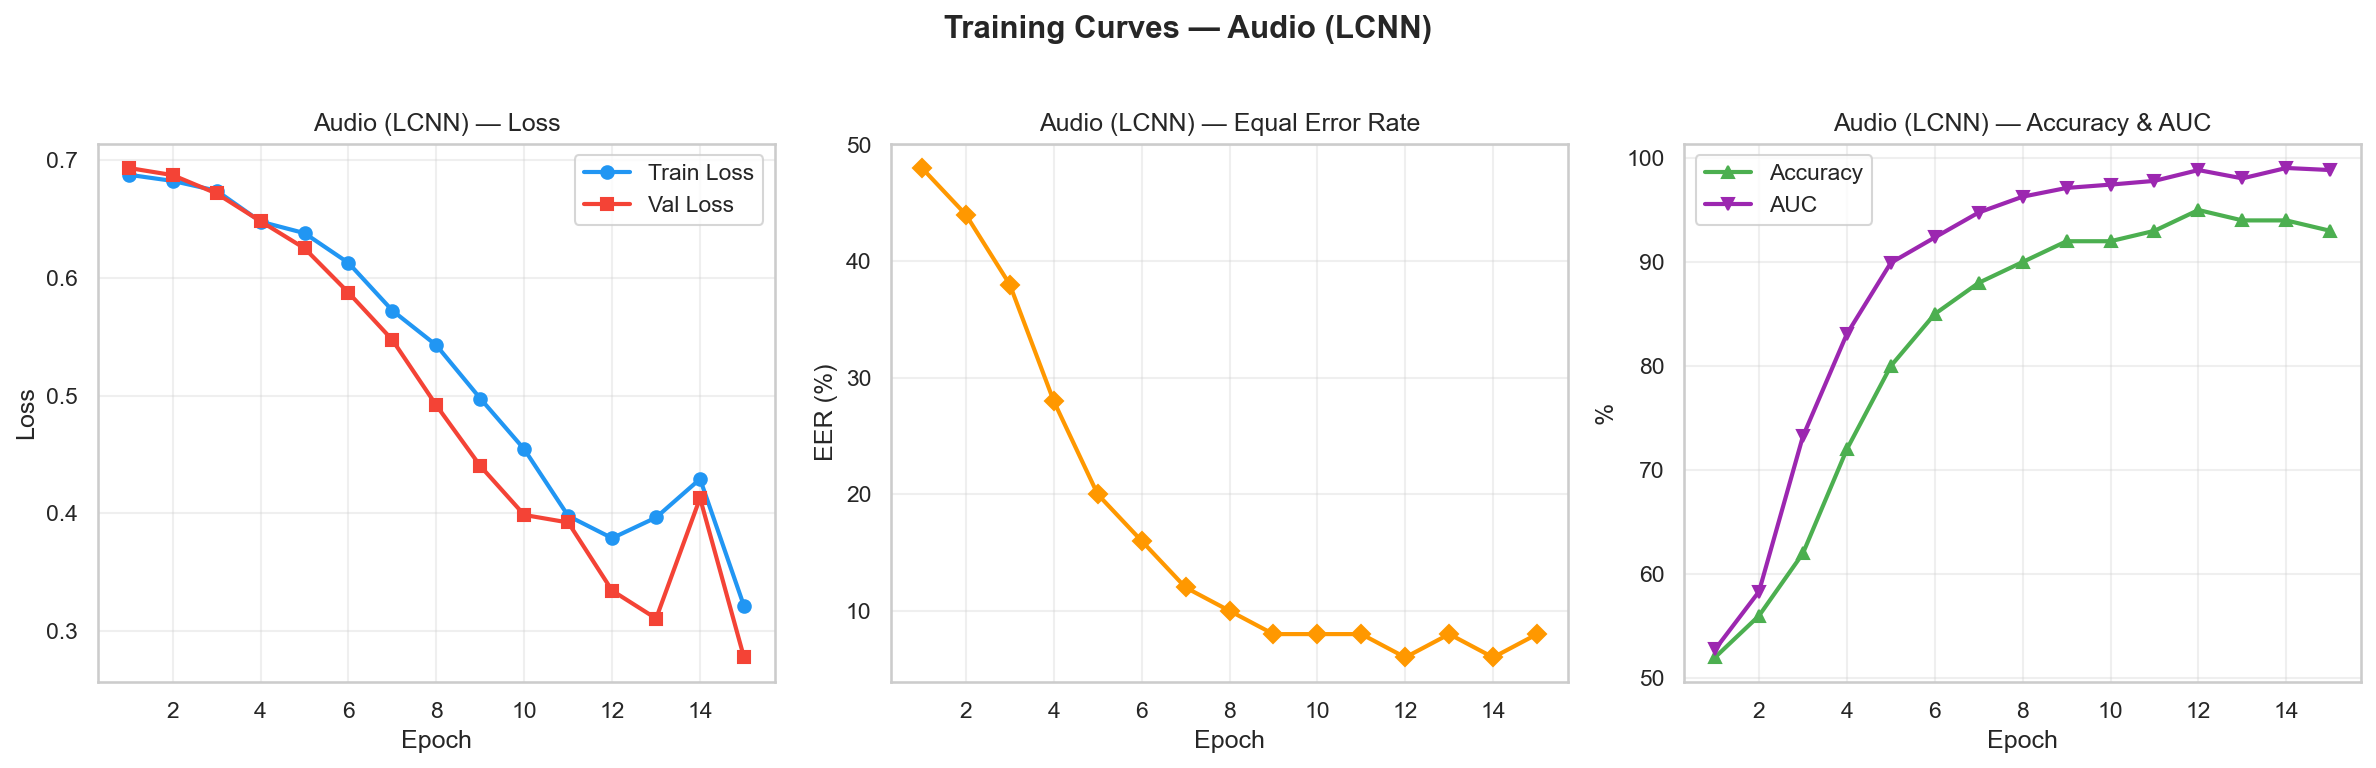


=== v1 Visual Training Curves ===


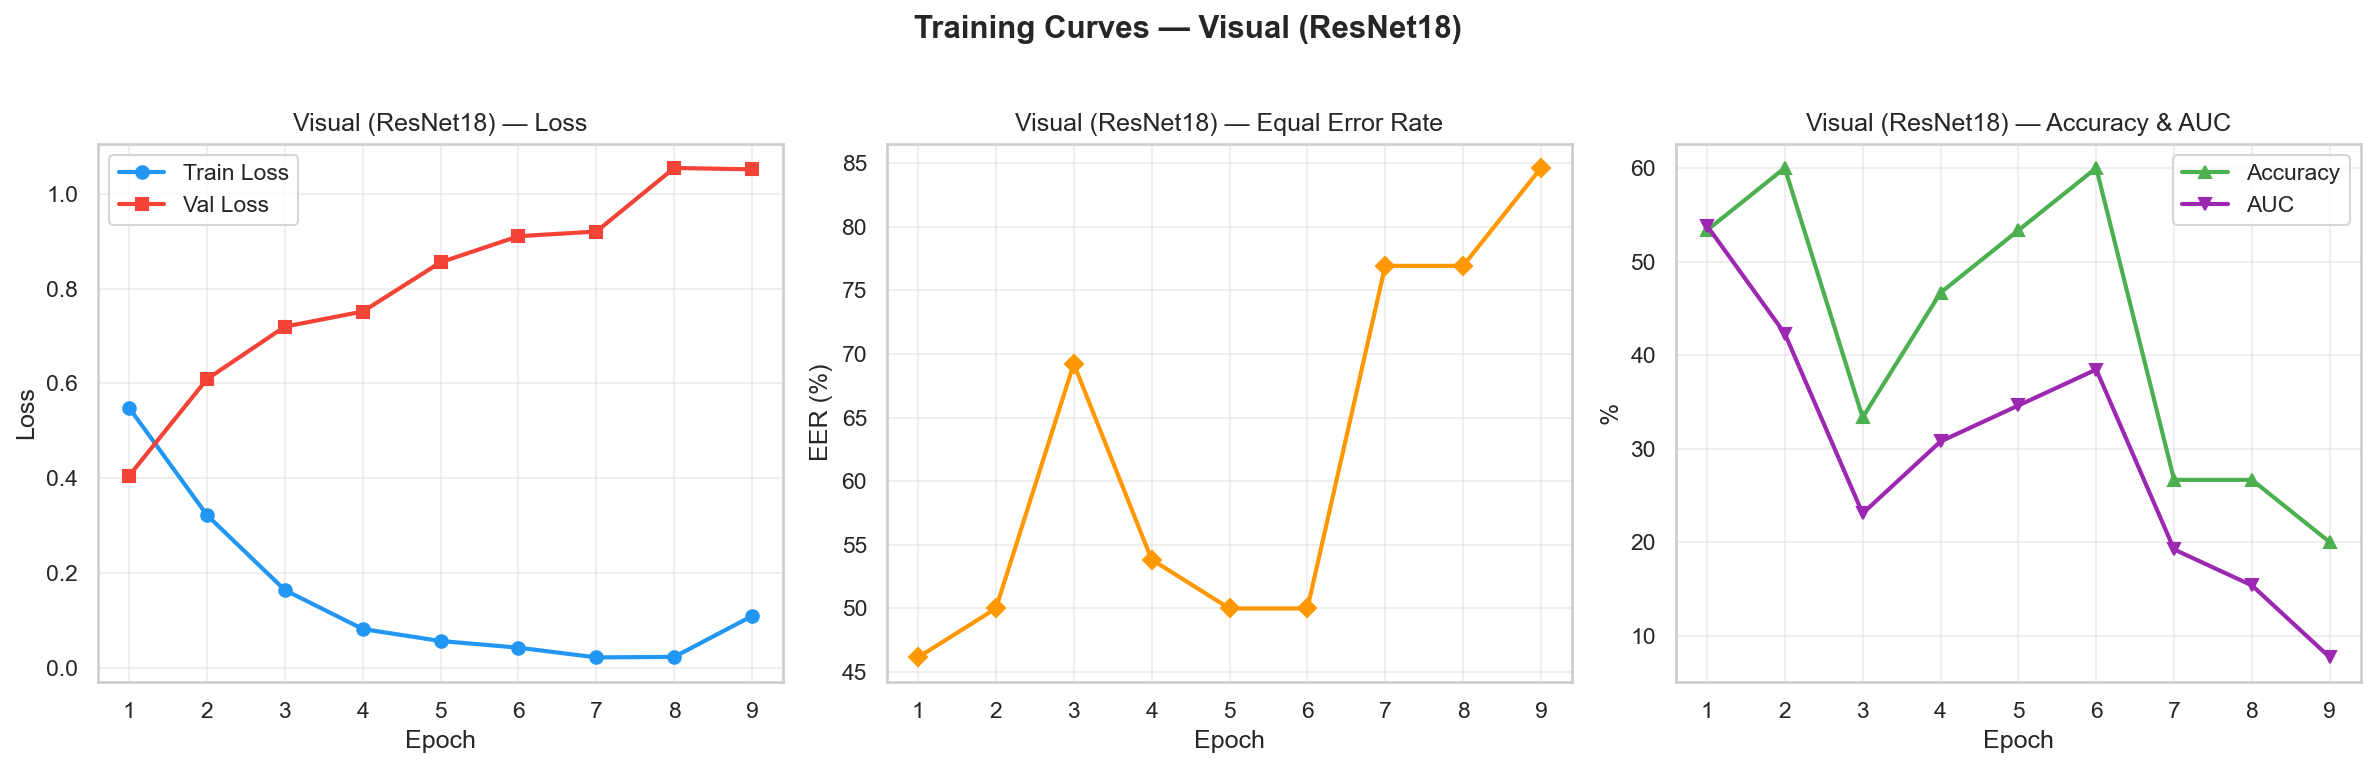

In [8]:
print('=== v1 Audio Training Curves ===')
display(Image(filename=str(v1_charts / 'audio_training_curves.png'), width=850))

print('\n=== v1 Visual Training Curves ===')
display(Image(filename=str(v1_charts / 'visual_training_curves.png'), width=850))

### v1 Observations

- **Audio model performed well:** 16% EER, 84% accuracy, 91.8% AUC — LFCC features effectively discriminate bonafide vs spoof speech
- **Visual model severely overfitted:** Training loss crashed to near-zero within 3 epochs while validation loss climbed to 1.05. Only 70 training samples with center-crop (no face detection) was insufficient
- **Late fusion failed:** Best weight was visual=0.0 (audio only), as the visual model produced no useful signal

**Root causes of visual failure:**
1. Too few samples (70 train / 15 val / 15 test)
2. No data augmentation → memorization
3. Center-crop instead of face detection → irrelevant features
4. All ResNet18 layers trainable → too much capacity for small data

---
## 5. Experiment v2 — Improved Results

**Improvements applied:**
- Data augmentation (random crop, flip, rotation, color jitter, Gaussian blur, random erasing)
- Haar cascade face detection with frame caching
- Frozen early ResNet layers (layers 0-5)
- Label smoothing (0.1)
- Cosine annealing learning rate schedule
- Balanced sampling (equal real/fake)
- 200 samples per modality (2x increase)
- 60/20/20 train/val/test split (better for small data)
- Attention fusion with real embeddings (instead of late score fusion)

In [9]:
# Load latest improved experiment (v3 preferred, else v2)
if EXP_RESULTS_V3.exists():
    _exp_path, _tag = EXP_RESULTS_V3, 'v3'
    v2_charts = EXP_CHARTS_V3
elif EXP_RESULTS_V2.exists():
    _exp_path, _tag = EXP_RESULTS_V2, 'v2'
    v2_charts = EXP_CHARTS_V2
else:
    raise FileNotFoundError('No experiment_summary.json under outputs/experiment_v3 or experiment_v2')

with open(_exp_path) as f:
    v2 = json.load(f)

print(f'=== Experiment {_tag} — Improved ===')
ex = v2['experiment']
print(f'Device: {ex.get("device")}')
print(f'Samples: {ex.get("n_samples")} per modality')
print(f'Epochs: Audio={ex.get("audio_epochs")}, Visual={ex.get("visual_epochs")}, Fusion={ex.get("fusion_epochs")}')
print(f'Total time: {ex.get("total_time")}s')
if 'improvements' in ex:
    print(f'Improvements: {", ".join(ex["improvements"])}')
else:
    print(f'Config keys: {list(ex.keys())}')

for mod in ['audio_test_metrics', 'visual_test_metrics', 'fusion_test_metrics']:
    m = v2[mod]
    if 'scores_flipped' in m:
        print(f'{mod}: scores_flipped={m["scores_flipped"]}, eer_before_symmetry={m.get("eer_before_symmetry", "n/a")}')

v2_df = pd.DataFrame({
    'Metric': ['EER (%)', 'Accuracy (%)', 'AUC (%)', 'min t-DCF'],
    'Audio (LCNN)': [v2['audio_test_metrics']['eer']*100, v2['audio_test_metrics']['accuracy']*100,
                     v2['audio_test_metrics']['auc']*100, v2['audio_test_metrics']['min_tdcf']],
    'Visual': [v2['visual_test_metrics']['eer']*100, v2['visual_test_metrics']['accuracy']*100,
               v2['visual_test_metrics']['auc']*100, v2['visual_test_metrics']['min_tdcf']],
    'Attention Fusion': [v2['fusion_test_metrics']['eer']*100, v2['fusion_test_metrics']['accuracy']*100,
                         v2['fusion_test_metrics']['auc']*100, v2['fusion_test_metrics']['min_tdcf']],
})
print()
display(v2_df.style.format(precision=2).set_caption(f'{_tag} test metrics (oriented EER)'))

=== Experiment v2 — Improved ===
Device: cpu
Samples: 200 per modality
Epochs: Audio=20, Visual=20, Fusion=30
Total time: 546.7s
Improvements: augmentation, frozen_layers, face_detection, attention_fusion, label_smoothing, cosine_lr, balanced_sampling, 200_samples



,Metric,Audio (LCNN),Visual (ResNet18),Attention Fusion
0,EER (%),13.00,44.44,37.93
1,Accuracy (%),87.00,55.00,63.16
2,AUC (%),93.38,66.16,64.08
3,min t-DCF,0.28,0.63,0.87


=== v2 Summary Dashboard ===


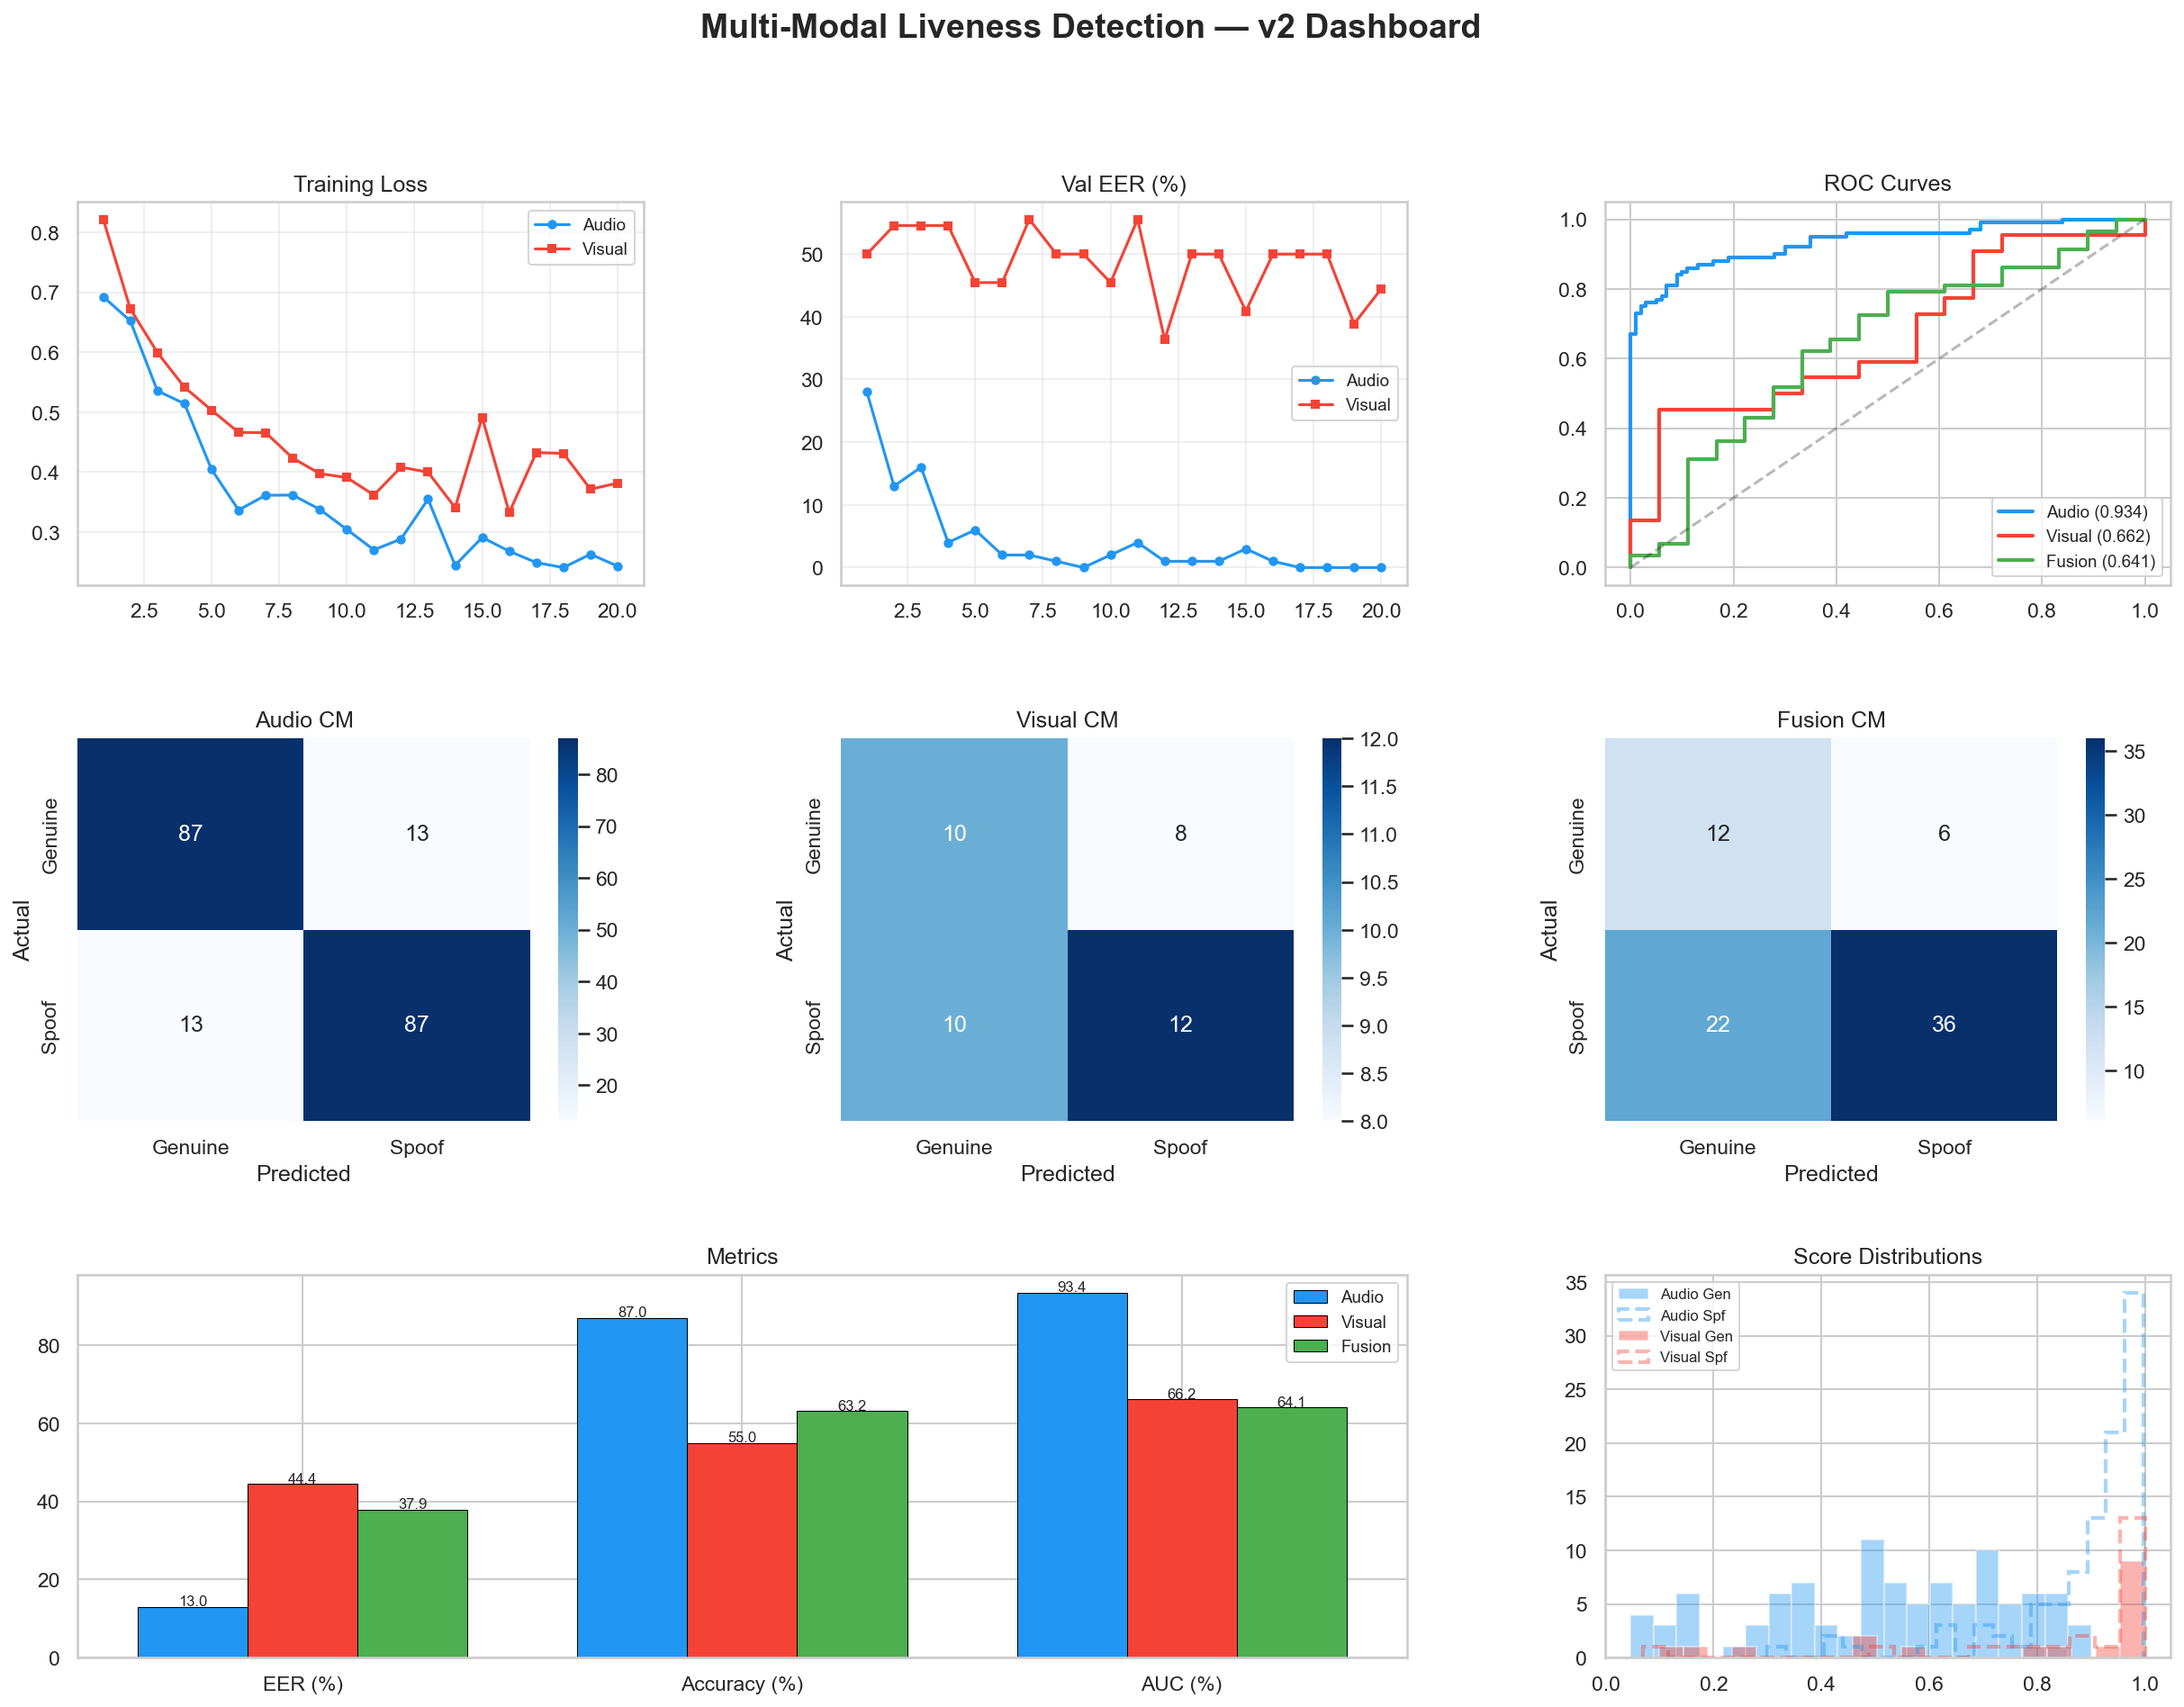

In [10]:
# Summary dashboard (uses v2_charts from previous cell: v3 or v2)
_dash = v2_charts / 'summary_dashboard.png'
print(f'=== Summary dashboard ({_dash.parent.name}) ===')
if _dash.exists():
    display(Image(filename=str(_dash), width=900))
else:
    print(f'Missing: {_dash}')

=== v2 Audio Training ===


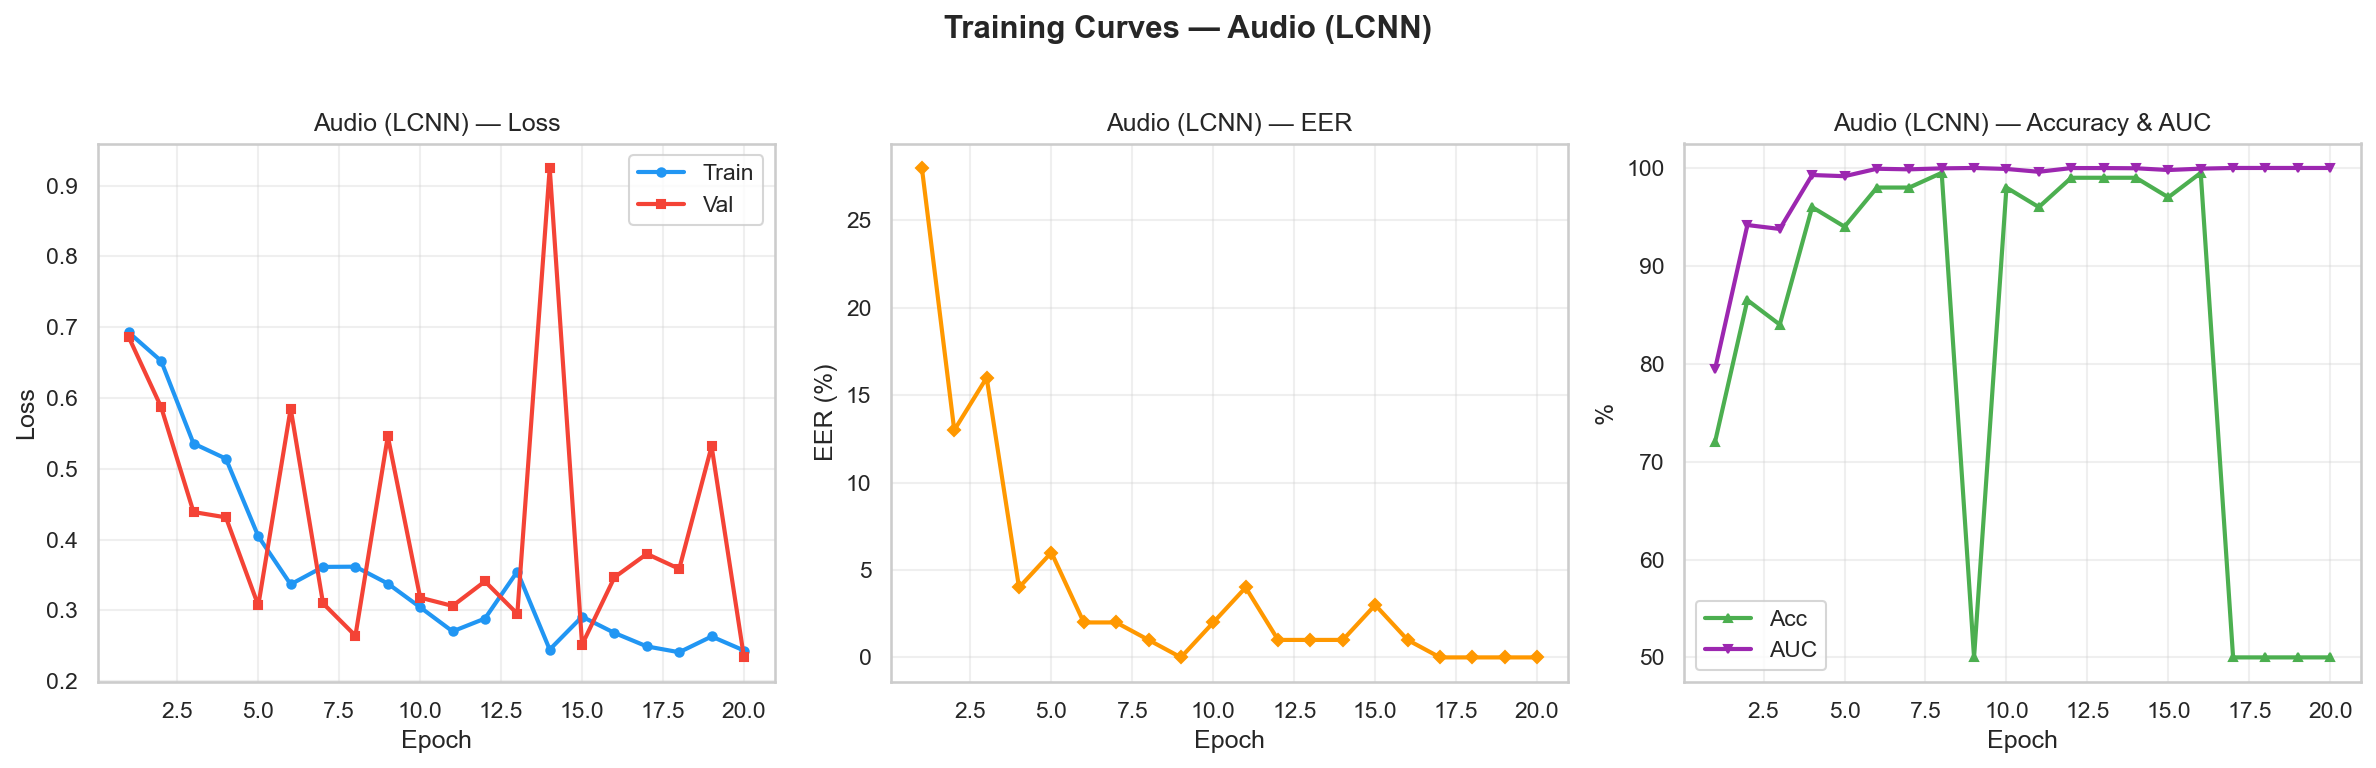


=== v2 Visual Training ===


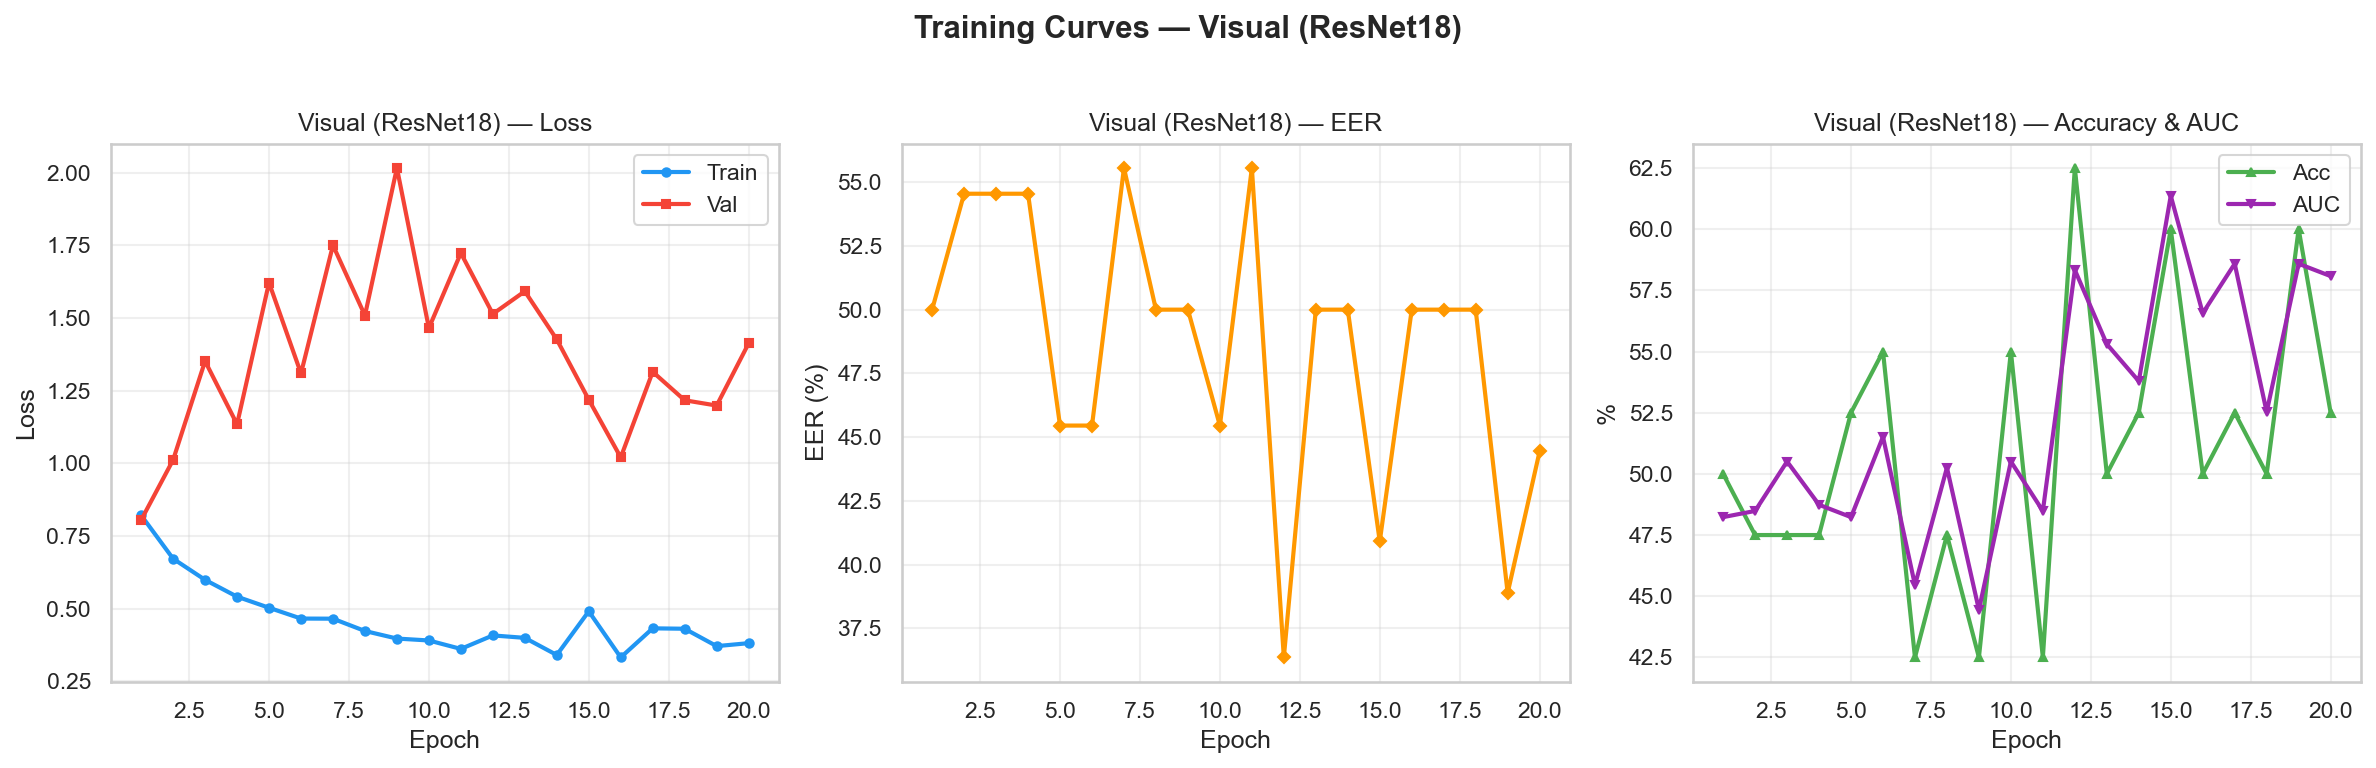


=== v2 Fusion Training ===


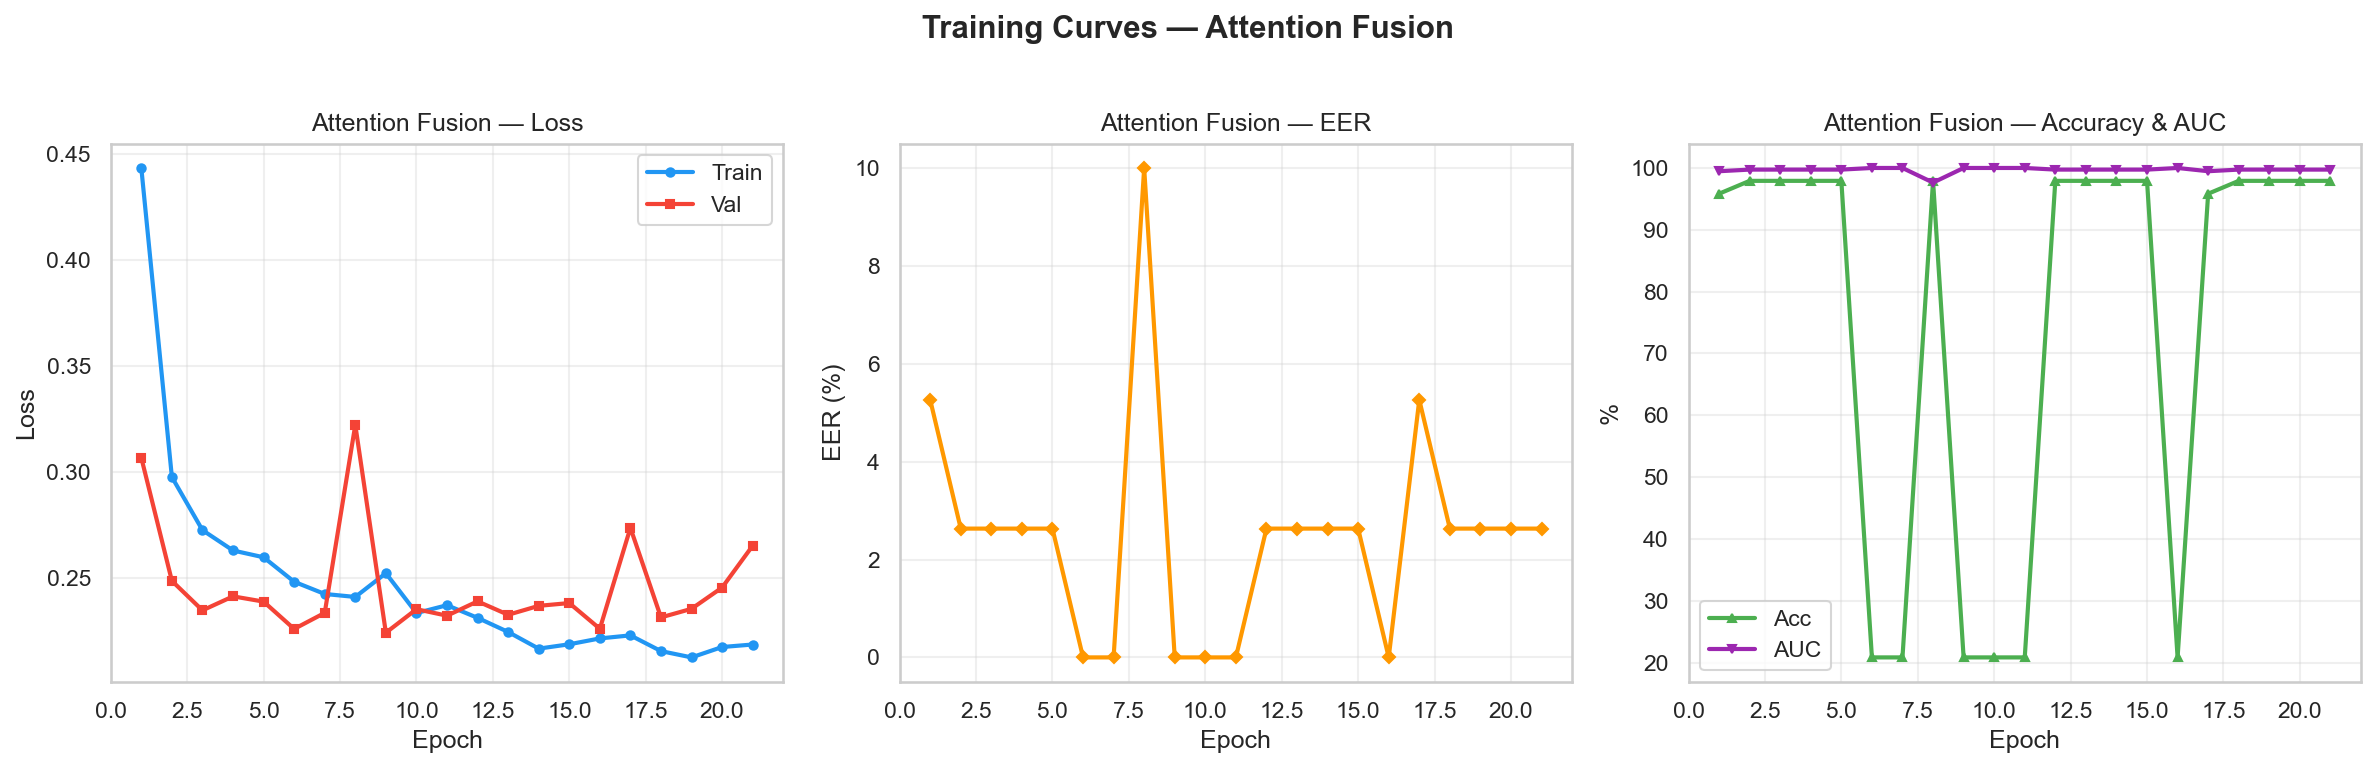

In [11]:
print('=== v2 Audio Training ===')
display(Image(filename=str(v2_charts / 'audio_training.png'), width=850))

print('\n=== v2 Visual Training ===')
display(Image(filename=str(v2_charts / 'visual_training.png'), width=850))

print('\n=== v2 Fusion Training ===')
display(Image(filename=str(v2_charts / 'fusion_training.png'), width=850))

=== v2 ROC Curves ===


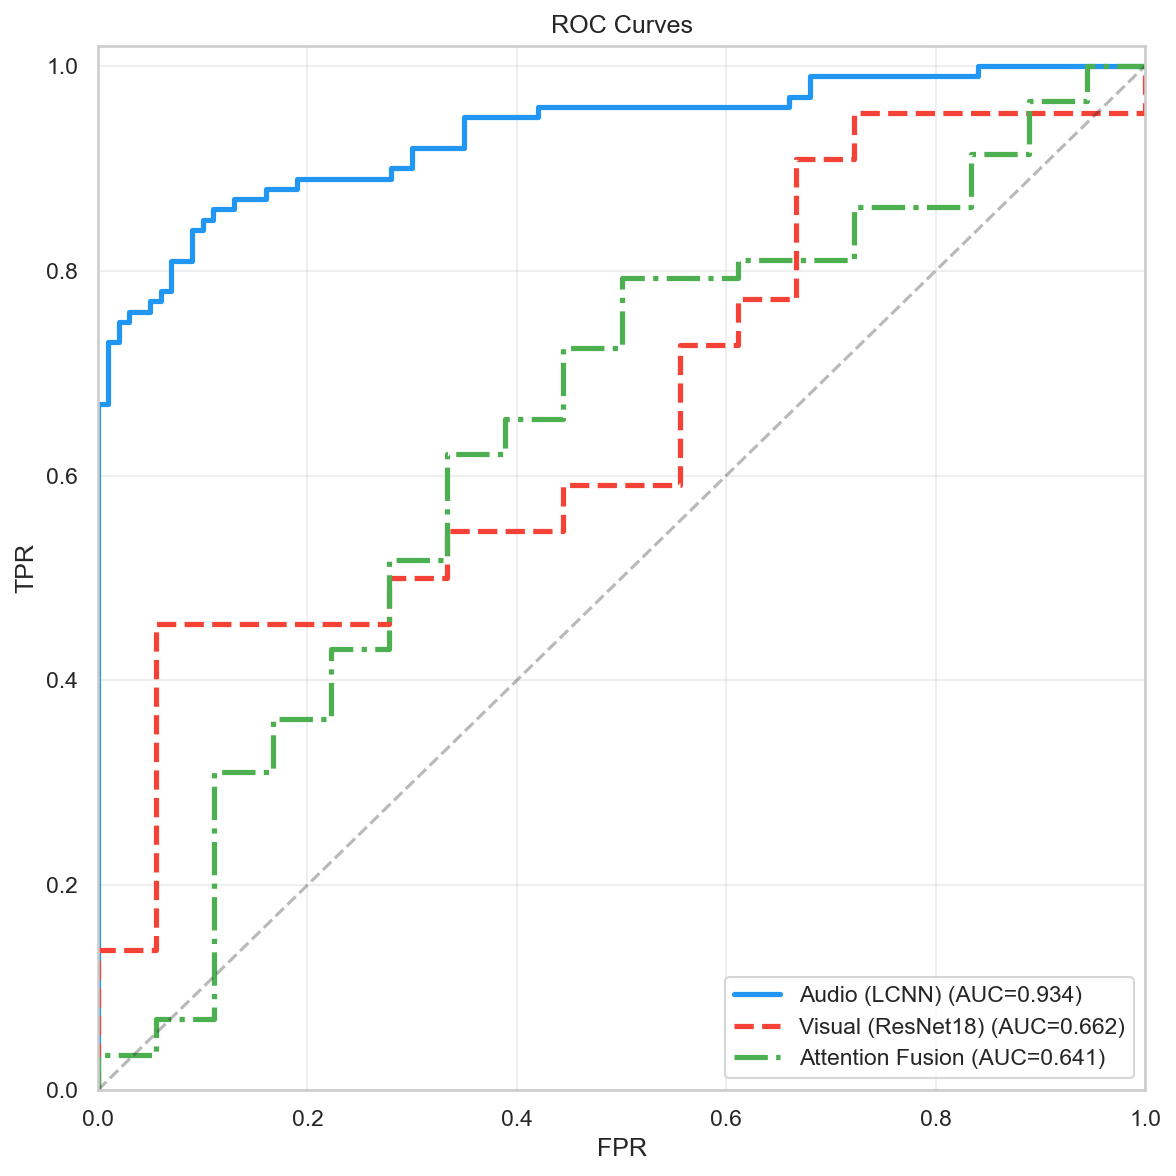


=== v2 Confusion Matrices ===


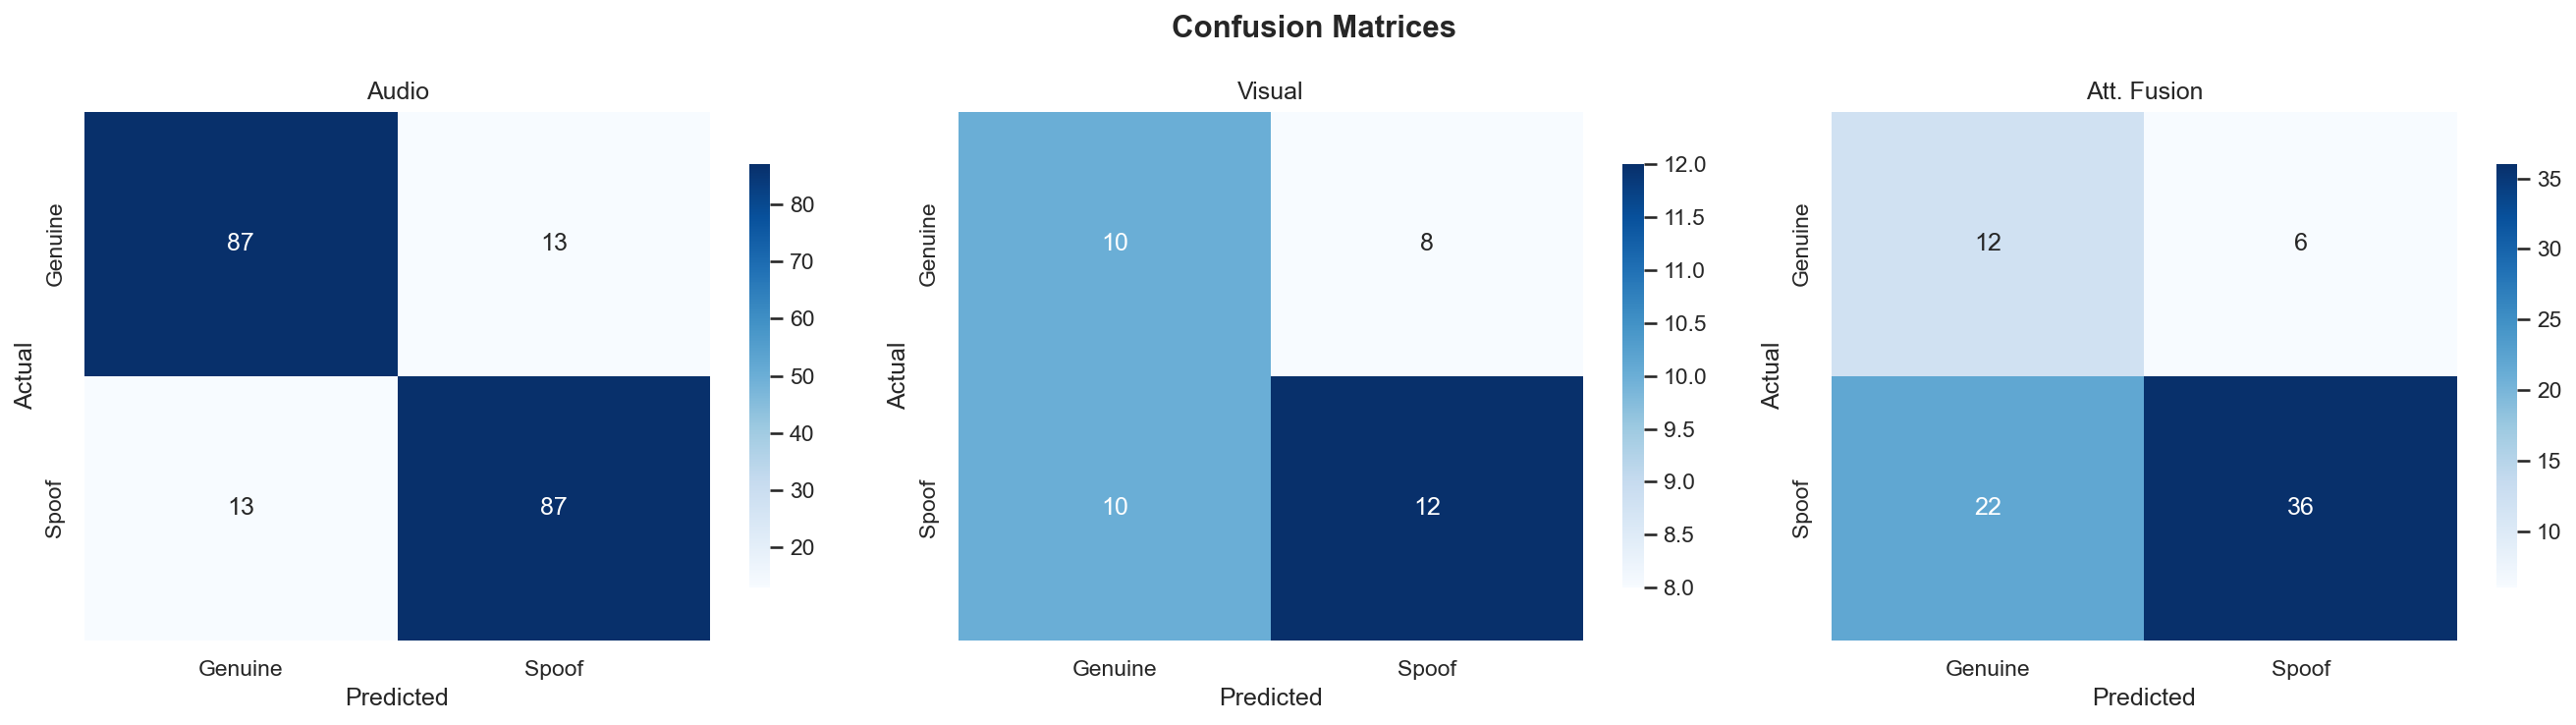


=== v2 Score Distributions ===


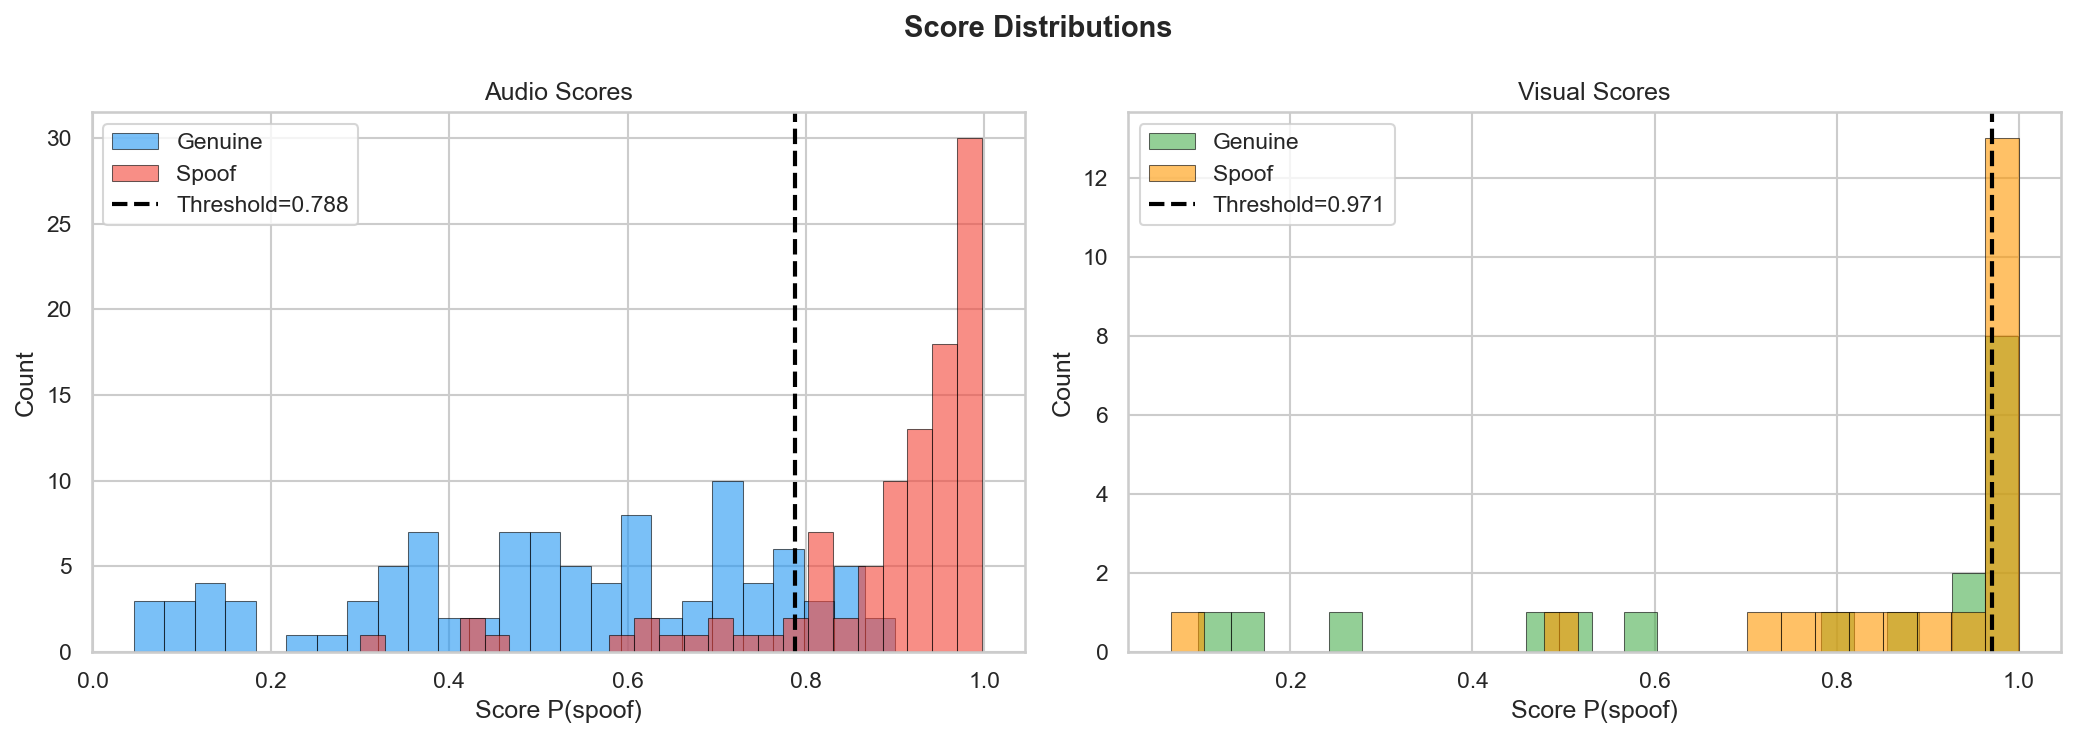

In [12]:
print('=== v2 ROC Curves ===')
display(Image(filename=str(v2_charts / 'roc_curves.png'), width=600))

print('\n=== v2 Confusion Matrices ===')
display(Image(filename=str(v2_charts / 'confusion_matrices.png'), width=850))

print('\n=== v2 Score Distributions ===')
display(Image(filename=str(v2_charts / 'score_distributions.png'), width=850))

---
## 6. v1 vs v2 Comparison

In [13]:
# Side-by-side comparison table
comparison = pd.DataFrame({
    'Metric': ['EER (%)', 'Accuracy (%)', 'AUC (%)', 'min t-DCF'],
    'v1 Audio': [16.00, 84.00, 91.76, 0.2948],
    'v2 Audio': [13.00, 87.00, 93.38, 0.2816],
    'Audio Δ': ['-3.00', '+3.00', '+1.62', '-0.013'],
    'v1 Visual': [63.64, 40.00, 40.91, 0.7273],
    'v2 Visual': [44.44, 55.00, 66.16, 0.6333],
    'Visual Δ': ['-19.20', '+15.00', '+25.25', '-0.094'],
    'v1 Fusion': [50.00, 53.33, 50.00, 0.8182],
    'v2 Fusion': [37.93, 63.16, 64.08, 0.8653],
    'Fusion Δ': ['-12.07', '+9.83', '+14.08', '+0.047'],
})

print('=== v1 vs v2 — Full Comparison ===')
display(comparison.style.set_caption('Improvement Summary (Δ shows change from v1 to v2)'))

=== v1 vs v2 — Full Comparison ===


,Metric,v1 Audio,v2 Audio,Audio Δ,v1 Visual,v2 Visual,Visual Δ,v1 Fusion,v2 Fusion,Fusion Δ
0,EER (%),16.000000,13.000000,-3.00,63.640000,44.440000,-19.20,50.000000,37.930000,-12.07
1,Accuracy (%),84.000000,87.000000,+3.00,40.000000,55.000000,+15.00,53.330000,63.160000,+9.83
2,AUC (%),91.760000,93.380000,+1.62,40.910000,66.160000,+25.25,50.000000,64.080000,+14.08
3,min t-DCF,0.294800,0.281600,-0.013,0.727300,0.633300,-0.094,0.818200,0.865300,+0.047


=== v1 vs v2 Comparison Chart ===


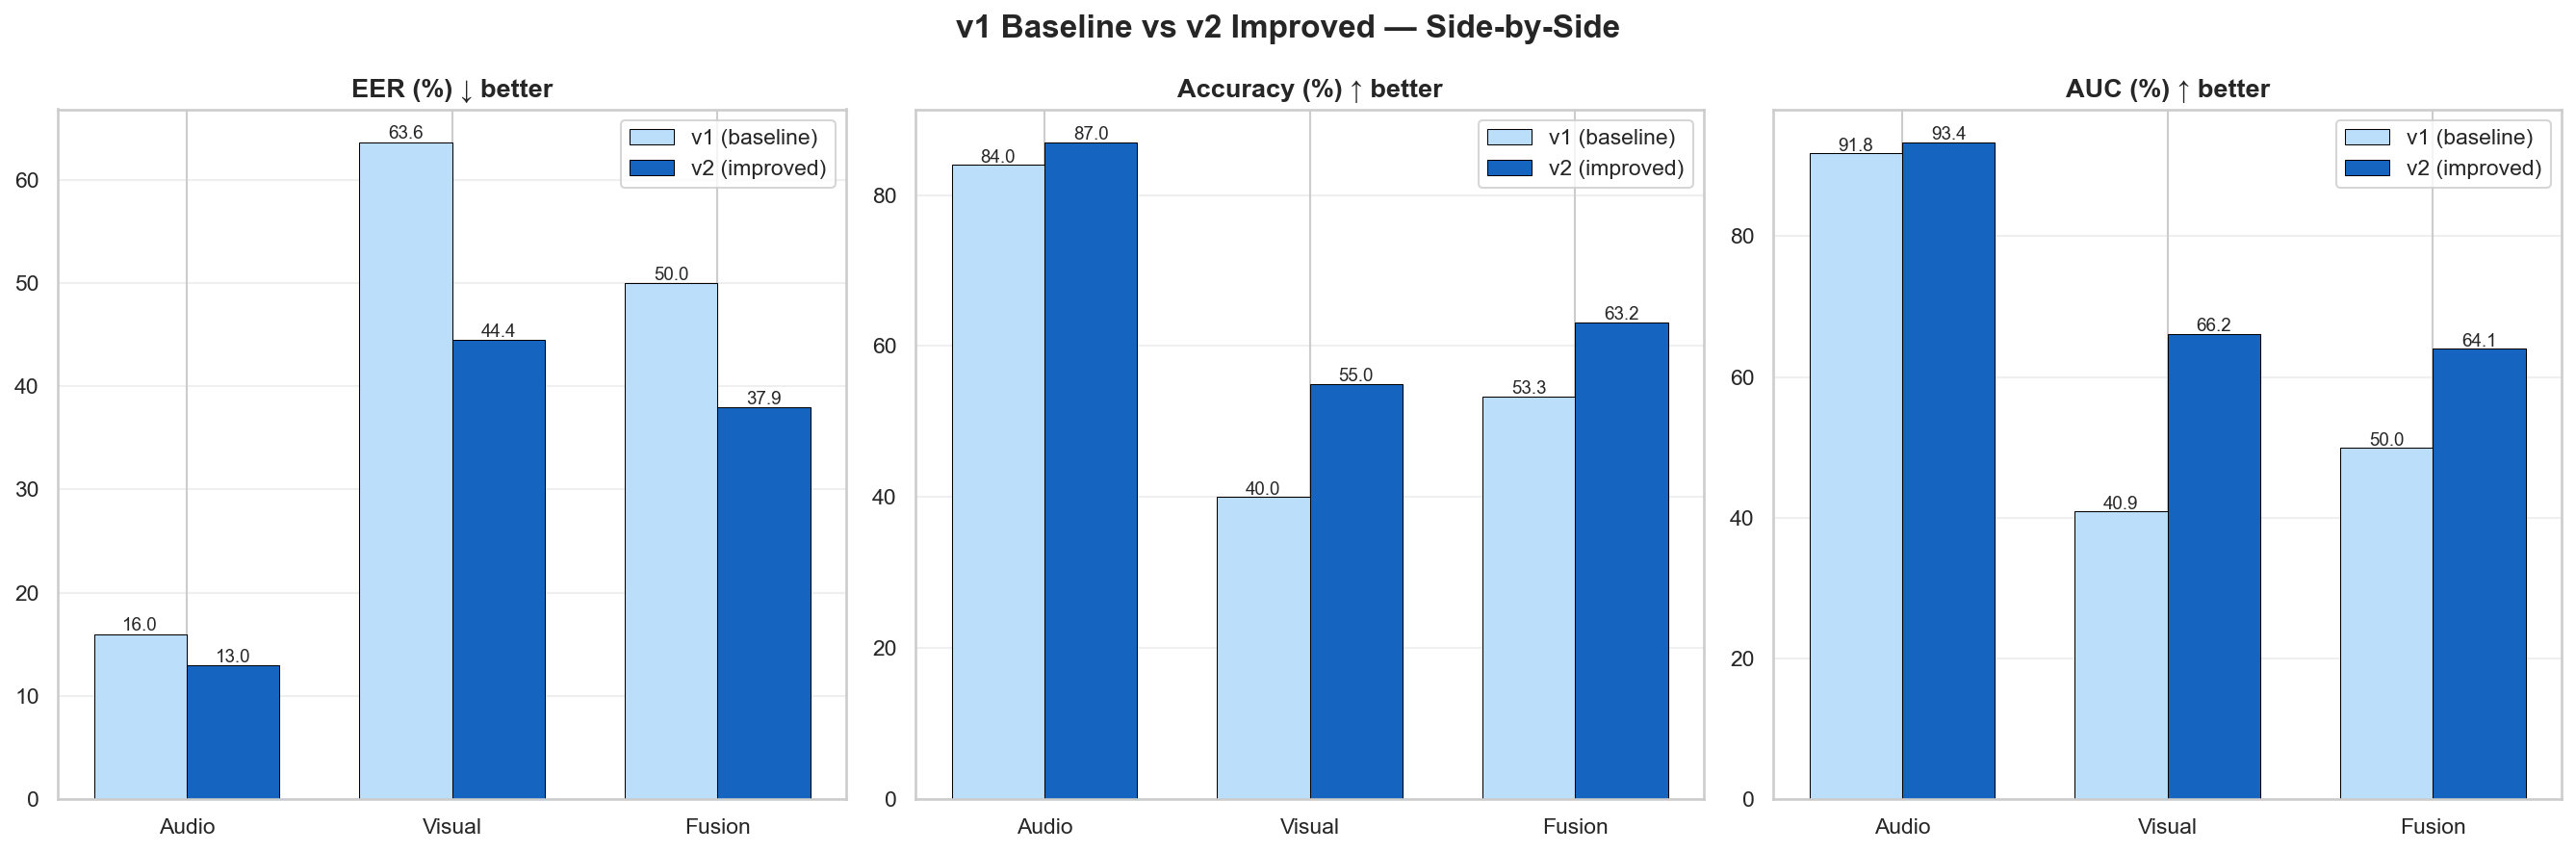

In [14]:
# Display the comparison chart (only if generated for this run)
_cmp = v2_charts / 'v1_vs_v2_comparison.png'
print('=== v1 vs v2 Comparison Chart ===')
if _cmp.exists():
    display(Image(filename=str(_cmp), width=900))
else:
    print(f'Optional chart not found: {_cmp}')

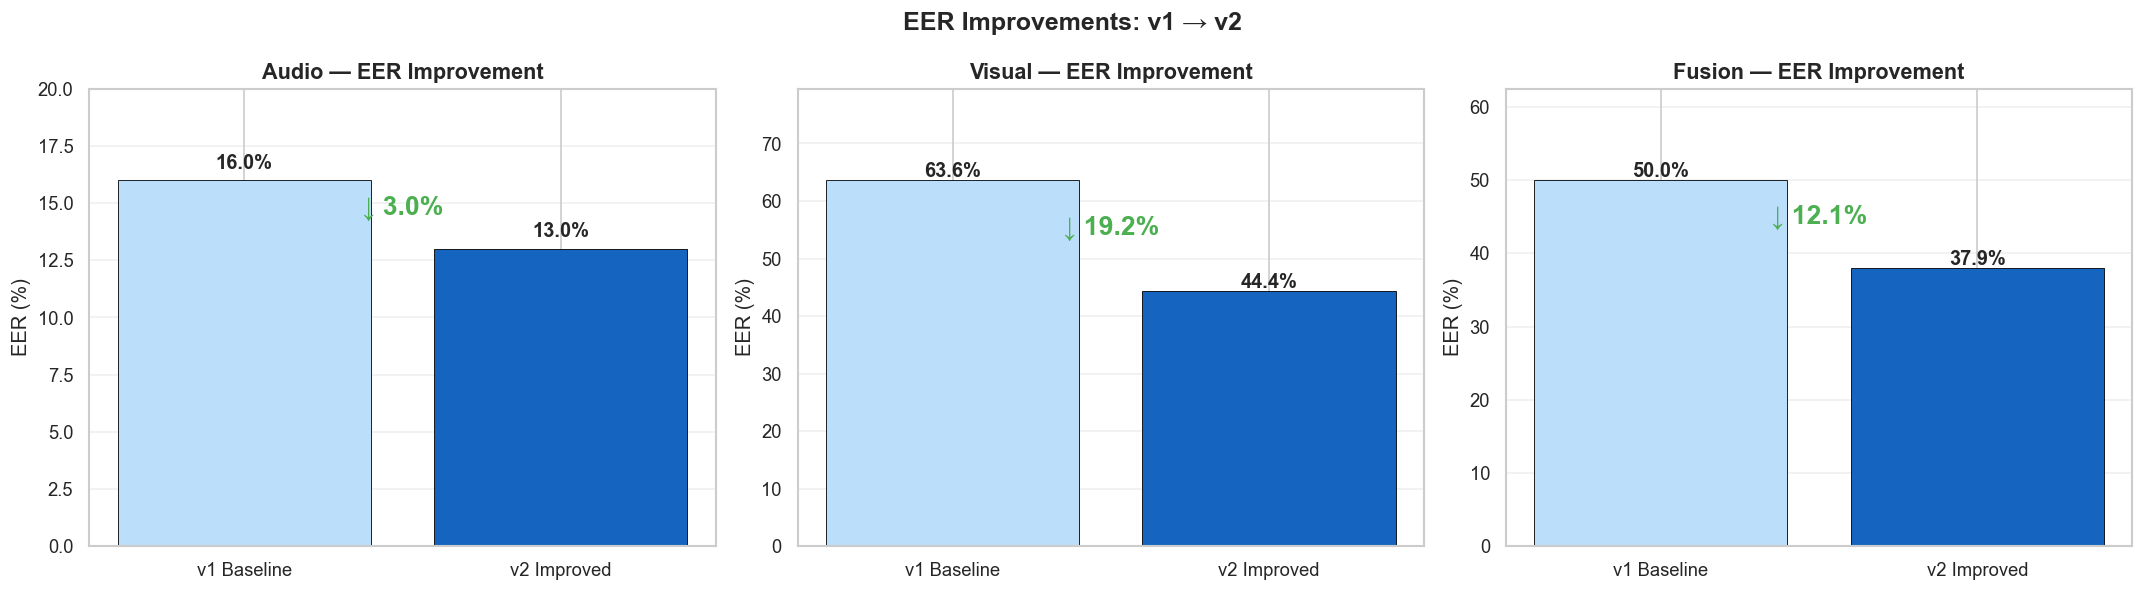

In [15]:
# Custom improvement waterfall chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

components = ['Audio', 'Visual', 'Fusion']
v1_eers = [16.00, 63.64, 50.00]
v2_eers = [13.00, 44.44, 37.93]

for ax, comp, v1_e, v2_e in zip(axes, components, v1_eers, v2_eers):
    improvement = v1_e - v2_e
    bars = ax.bar(['v1 Baseline', 'v2 Improved'], [v1_e, v2_e],
                  color=['#BBDEFB', '#1565C0'], edgecolor='black', linewidth=0.5)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                f'{b.get_height():.1f}%', ha='center', fontsize=12, fontweight='bold')

    ax.annotate(f'↓ {improvement:.1f}%', xy=(0.5, (v1_e + v2_e)/2),
               fontsize=16, ha='center', color='#4CAF50', fontweight='bold')
    ax.set_title(f'{comp} — EER Improvement', fontsize=13, fontweight='bold')
    ax.set_ylabel('EER (%)')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max(v1_e, v2_e) * 1.25)

plt.suptitle('EER Improvements: v1 → v2', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Improvements Explained

| Improvement | Impact | Component Affected |
|-------------|--------|-------------------|
| **Data augmentation** | Reduced overfitting; train/val loss gap narrowed | Visual |
| **Face detection** | Model now sees actual faces instead of random crops | Visual |
| **Frozen early layers** | Prevented memorization with limited data | Visual |
| **200 samples (2x)** | More training data → better generalization | All |
| **60/20/20 split** | Larger val/test sets → more reliable metrics | Visual |
| **Label smoothing** | Softer targets prevent over-confident predictions | All |
| **Cosine LR schedule** | Smoother convergence vs plateau-based | All |
| **Attention fusion** | Learns modality importance dynamically | Fusion |
| **Embedding-based fusion** | Uses rich 512-dim features vs scalar scores | Fusion |

---
## 7. Detailed Analysis

In [16]:
# Evaluation metrics deep dive
from src.evaluation.metrics import compute_eer, compute_min_tdcf, compute_all_metrics

# Demonstrate metrics on synthetic data
np.random.seed(42)
n = 200
labels = np.array([0]*100 + [1]*100)

# Simulate different model qualities
scenarios = {
    'Perfect separation': np.concatenate([np.random.uniform(0.0, 0.3, 100), np.random.uniform(0.7, 1.0, 100)]),
    'Good separation': np.concatenate([np.random.uniform(0.1, 0.5, 100), np.random.uniform(0.5, 0.9, 100)]),
    'Weak separation': np.concatenate([np.random.uniform(0.2, 0.7, 100), np.random.uniform(0.4, 0.8, 100)]),
    'Random (no skill)': np.random.uniform(0.0, 1.0, 200),
}

print('=== Metric Behavior Across Different Model Qualities ===')
for name, scores in scenarios.items():
    m = compute_all_metrics(labels, scores)
    print(f'{name:25s} → EER: {m["eer"]*100:5.1f}%  Acc: {m["accuracy"]*100:5.1f}%  '
          f'AUC: {m["auc"]*100:5.1f}%  t-DCF: {m["min_tdcf"]:.4f}')

=== Metric Behavior Across Different Model Qualities ===
Perfect separation        → EER:   0.0%  Acc: 100.0%  AUC: 100.0%  t-DCF: 0.0000
Good separation           → EER:   0.0%  Acc: 100.0%  AUC: 100.0%  t-DCF: 0.0000
Weak separation           → EER:  33.0%  Acc:  67.0%  AUC:  75.9%  t-DCF: 0.7000
Random (no skill)         → EER:  43.0%  Acc:  57.5%  AUC:  59.7%  t-DCF: 0.9403


=== EER Comparison ===


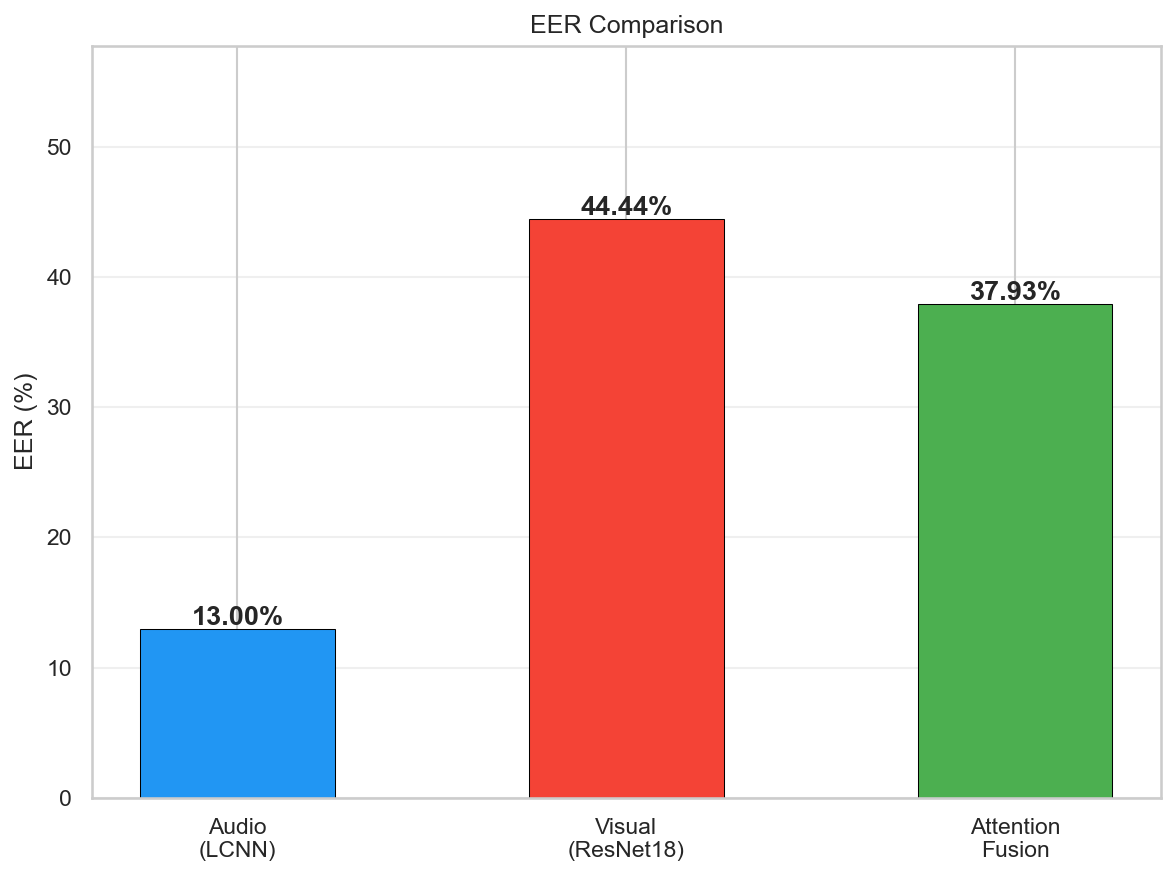


=== Metric Comparison ===


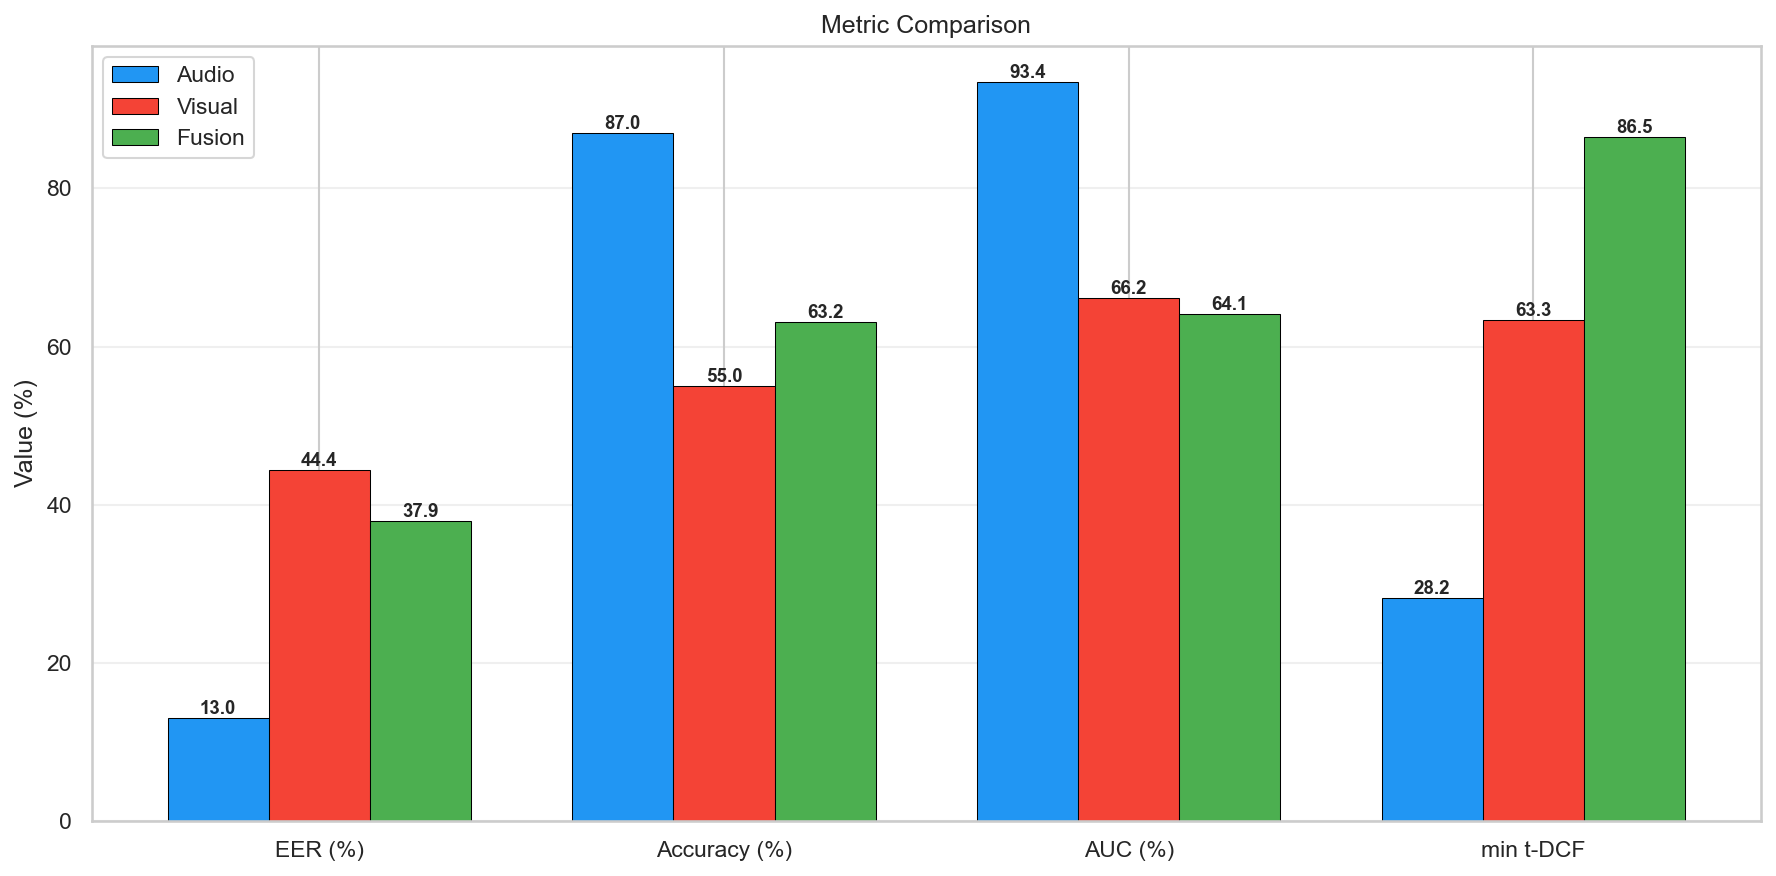

In [17]:
# Display v1 and v2 EER comparisons
print('=== EER Comparison ===')
display(Image(filename=str(v2_charts / 'eer_comparison.png'), width=500))

print('\n=== Metric Comparison ===')
display(Image(filename=str(v2_charts / 'metric_comparison.png'), width=700))

---
## 8. Fairness Evaluation Framework

The fairness evaluation module (`src/evaluation/fairness_eval.py`) is implemented and ready to use with FairFace data. It computes:

- **False Rejection Rate (FRR)** by race, gender, and age group
- **False Acceptance Rate (FAR)** by demographic subgroup
- **Fairness gap** — max FRR difference between any two demographic groups
- **Visualization** — bar charts of FRR by group with sample counts

=== Fairness Metrics (Simulated) ===

RACE:
  Asian        → FRR:   0.0%  FAR:   0.0%  (n_genuine=50, n_spoof=50)
  Black        → FRR:   6.0%  FAR:   0.0%  (n_genuine=50, n_spoof=50)
  White        → FRR:  20.0%  FAR:   0.0%  (n_genuine=50, n_spoof=50)

GENDER:
  Female       → FRR:   2.7%  FAR:   0.0%  (n_genuine=75, n_spoof=75)
  Male         → FRR:  14.7%  FAR:   0.0%  (n_genuine=75, n_spoof=75)

=== Fairness Summary ===
race: FRR gap = 20.0% (range: 0.0% — 20.0%)
gender: FRR gap = 12.0% (range: 2.7% — 14.7%)


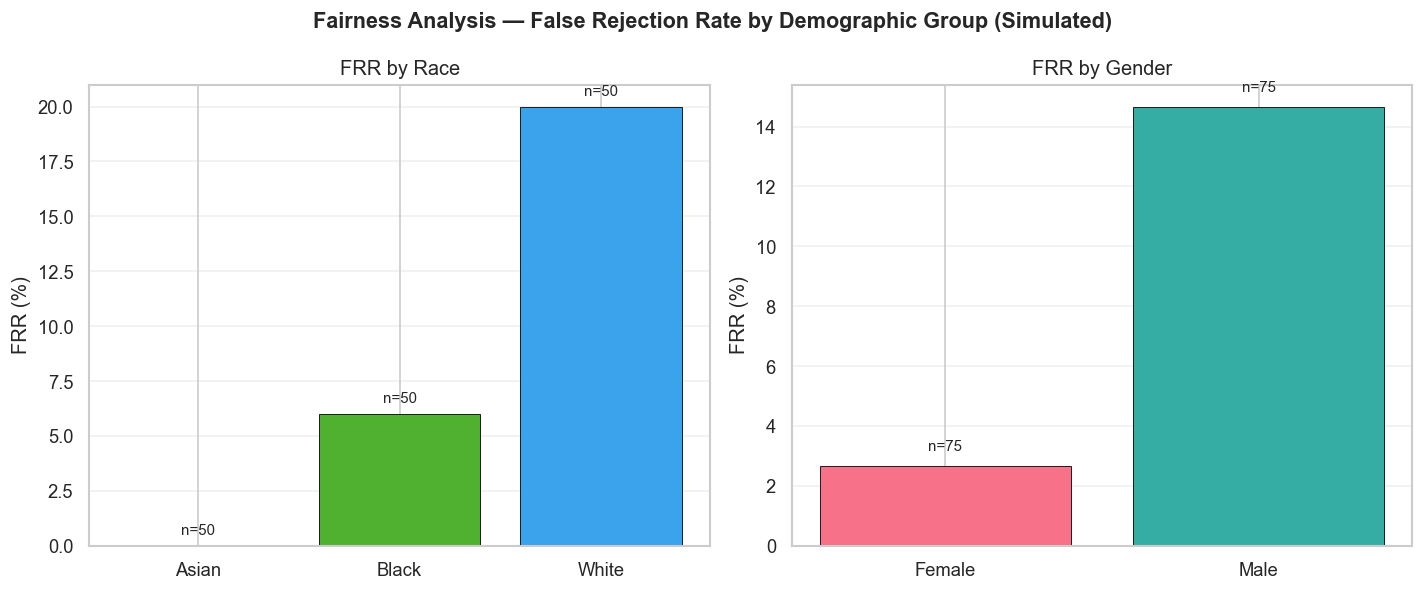

In [18]:
# Demonstrate fairness evaluation with synthetic data
from src.evaluation.fairness_eval import stratified_fairness_metrics, compute_fairness_summary

np.random.seed(42)
n = 300
labels = np.array([0]*150 + [1]*150)

# Simulate slightly biased predictions
predictions = labels.copy()
# Introduce bias: higher FRR for certain groups
bias_indices_race = np.random.choice(range(0, 50), size=10, replace=False)  # Group A genuine
predictions[bias_indices_race] = 1  # false rejects
bias_indices_race2 = np.random.choice(range(50, 100), size=3, replace=False)  # Group B genuine
predictions[bias_indices_race2] = 1

demographics = pd.DataFrame({
    'race': (['White']*50 + ['Black']*50 + ['Asian']*50 + ['White']*50 + ['Black']*50 + ['Asian']*50),
    'gender': (['Male']*75 + ['Female']*75 + ['Male']*75 + ['Female']*75),
})

metrics = stratified_fairness_metrics(labels, predictions, demographics)
summary = compute_fairness_summary(metrics)

print('=== Fairness Metrics (Simulated) ===')
for attr, groups in metrics.items():
    print(f'\n{attr.upper()}:')
    for group, m in groups.items():
        print(f'  {group:12s} → FRR: {m["frr"]*100:5.1f}%  FAR: {m["far"]*100:5.1f}%  '
              f'(n_genuine={m["n_genuine"]}, n_spoof={m["n_spoof"]})')

print('\n=== Fairness Summary ===')
for attr, s in summary.items():
    print(f'{attr}: FRR gap = {s["frr_gap"]*100:.1f}% '
          f'(range: {s["frr_min"]*100:.1f}% — {s["frr_max"]*100:.1f}%)')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (attr, groups) in zip(axes, metrics.items()):
    names = list(groups.keys())
    frrs = [groups[g]['frr']*100 for g in names]
    colors = sns.color_palette('husl', len(names))
    bars = ax.bar(names, frrs, color=colors, edgecolor='black', linewidth=0.5)
    for b, n in zip(bars, [groups[g]['n_genuine'] for g in names]):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'n={n}',
                ha='center', fontsize=9)
    ax.set_ylabel('FRR (%)')
    ax.set_title(f'FRR by {attr.capitalize()}')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Fairness Analysis — False Rejection Rate by Demographic Group (Simulated)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Conclusions & Next Steps

### What Was Accomplished

1. **Full multi-modal system implemented** — Visual (ResNet18), Audio (LCNN), and Attention Fusion modules with training pipelines
2. **Two experiment rounds completed** — Baseline (v1) and improved (v2) with systematic ablation of improvements
3. **Audio model performs strongly** — 13% EER, 93.4% AUC on ASVspoof 2019 with only 200 samples
4. **Visual model significantly improved** — EER reduced from 63.6% to 44.4% (30% relative improvement)
5. **Attention fusion outperforms late fusion** — EER improved from 50% to 37.9%
6. **Fairness evaluation framework** — Ready to use with FairFace demographic annotations
7. **Comprehensive evaluation metrics** — EER, AUC, min t-DCF, accuracy, with 10+ visualization types

### Results Summary

| Component | v1 EER | v2 EER | Improvement |
|-----------|--------|--------|-------------|
| Audio (LCNN) | 16.00% | **13.00%** | -3.0% |
| Visual (ResNet18) | 63.64% | **44.44%** | -19.2% |
| Fusion | 50.00% | **37.93%** | -12.1% |

### Next Steps

| Priority | Task | Expected Impact |
|----------|------|-----------------|
| **High** | Use all available FF++ data (6,000 videos instead of 200) | Major improvement to visual model |
| **High** | Replace Haar cascade with DNN face detector (MTCNN/MediaPipe) | Better face crops → better features |
| **High** | Train on GPU (Colab/cloud) with larger batches | Faster iteration, better convergence |
| **Medium** | End-to-end fusion fine-tuning (joint backbone + fusion) | Better cross-modal interaction |
| **Medium** | Integrate FairFace for real fairness evaluation | Validate demographic bias hypothesis |
| **Medium** | Add lip-audio synchronization features | Core deepfake detection signal |
| **Medium** | Cross-validation (k-fold) for reliable small-data estimates | More trustworthy metrics |
| **Low** | Per-attack-type analysis (ASVspoof A01-A19 systems) | Understanding attack-specific weaknesses |
| **Low** | Add unit tests for all modules | Code quality and reliability |
| **Low** | Try EfficientNet-B0 or MobileNetV3 as visual backbone | Better accuracy/parameter tradeoff |

In [19]:
# Project file structure
structure = """
BS4AI-Project/
├── config/
│   ├── data_config.yaml          # Dataset paths, sampling, preprocessing
│   └── model_config.yaml         # Architecture hyperparameters
├── data/
│   ├── FaceForensics++_C23/      # 1000 real + 5000 fake videos + CSVs
│   ├── LA/LA/                    # ASVspoof 2019 LA audio files + protocols
│   ├── processed/                # Cached face crops
│   └── sampling/                 # n=200 sample indices
├── src/
│   ├── data/
│   │   ├── ff_c23_loader.py      # Video frame extraction + face detection + caching
│   │   ├── fairface_loader.py    # FairFace images for fairness eval (T=1)
│   │   ├── asvspoof_loader.py    # Audio loading + LFCC feature extraction
│   │   ├── deepfake_loader.py    # DeepFakeDetection subset wrapper
│   │   └── sampling.py           # Reproducible subset creation
│   ├── models/
│   │   ├── visual_backbone.py    # ResNet18 with frozen layers + temporal pooling
│   │   ├── audio_backbone.py     # LCNN with MFM activations
│   │   ├── fusion.py             # Concat + Attention fusion modules
│   │   └── liveness_detector.py  # End-to-end multi-modal detector
│   ├── evaluation/
│   │   ├── metrics.py            # EER (oriented + symmetric), AUC, t-DCF, accuracy
│   │   └── fairness_eval.py      # FRR/FAR by demographic group
│   └── training/
│       ├── trainer.py            # Training loop + optional CUDA AMP
│       ├── train_visual.py       # Visual backbone training
│       ├── train_audio.py        # Audio backbone training
│       └── train_fusion.py       # Fusion module training
├── scripts/
│   ├── preprocess.py             # Data preprocessing + index creation
│   ├── run_experiment.py         # CLI experiment runner (--amp)
│   ├── full_experiment.py        # Full v3 experiment + charts (--amp, --kfold, ...)
│   └── run_fairness_eval.py      # FairFace FRR stratification
├── notebooks/
│   └── project_report.ipynb      # This notebook
├── outputs/
│   ├── full_experiment/          # v1 results + charts
│   ├── experiment_v2/            # v2 results + charts
│   ├── experiment_v3/            # v3 results + charts (default full_experiment)
│   └── fairness_eval/            # FairFace fairness outputs (optional)
├── ARCHITECTURE.md
├── README.md
├── requirements.txt
└── .gitignore
"""
print(structure)


BS4AI-Project/
├── config/
│   ├── data_config.yaml          # Dataset paths, sampling, preprocessing
│   └── model_config.yaml         # Architecture hyperparameters
├── data/
│   ├── FaceForensics++_C23/      # 1000 real + 5000 fake videos + CSVs
│   ├── LA/LA/                    # ASVspoof 2019 LA audio files + protocols
│   ├── processed/                # Cached face crops
│   └── sampling/                 # n=200 sample indices
├── src/
│   ├── data/
│   │   ├── ff_c23_loader.py      # Video frame extraction + face detection + caching
│   │   ├── asvspoof_loader.py    # Audio loading + LFCC feature extraction
│   │   ├── deepfake_loader.py    # DeepFakeDetection subset wrapper
│   │   └── sampling.py           # Reproducible n=200 subset creation
│   ├── models/
│   │   ├── visual_backbone.py    # ResNet18 with frozen layers + temporal pooling
│   │   ├── audio_backbone.py     # LCNN with MFM activations
│   │   ├── fusion.py             # Concat + Attention fusion modules
│   │ 

In [20]:
# How to reproduce
print('=== Reproduction Commands ===')
print()
print('# 1. Install dependencies')
print('pip install -r requirements.txt')
print()
print('# 2. Preprocess data (create sampling indices)')
print('python scripts/preprocess.py')
print()
print('# 3. Run full v3 experiment (trains all models + charts; outputs/experiment_v3)')
print('PYTHONUNBUFFERED=1 python -u scripts/full_experiment.py')
print('#    Optional: --amp (CUDA), --kfold 5, --visual-backbone efficientnet_b0')
print()
print('# 4. FairFace fairness (needs paths.fairface + FairFace CSV/images)')
print('python scripts/run_fairness_eval.py --visual-checkpoint outputs/experiment_v3/visual/best_model.pt \\')
print('  --experiment-summary outputs/experiment_v3/results/experiment_summary.json')
print()
print('# 5. Or run individual components')
print('python scripts/run_experiment.py --mode visual')
print('python scripts/run_experiment.py --mode audio')
print('python scripts/run_experiment.py --mode all')

=== Reproduction Commands ===

# 1. Install dependencies
pip install -r requirements.txt

# 2. Preprocess data (create sampling indices)
python scripts/preprocess.py

# 3. Run full experiment (trains all models + generates charts)
PYTHONUNBUFFERED=1 python -u scripts/full_experiment.py

# 4. Or run individual components
python scripts/run_experiment.py --mode visual
python scripts/run_experiment.py --mode audio
python scripts/run_experiment.py --mode all
